# Init

In [3]:
import pandas as pd
from itables import show
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data

In [4]:
df_master = pd.read_csv('public_results/evaluation_metrics_l_2_h_1_hd_1024_trainable_True_lr_0.0001.csv')

In [5]:
df_master_all_users = df_master[(df_master['User_Type'] == 'all')].copy()
df_master_all_users

,User_Type,Weight_Profile,Model,k,HitRate,NDCG,unSerendipity,Train_Scenario,trainable
0,all,NaN,Base_SASRec,2,0.020537,0.017622,0.118138,1.0,True
1,all,NaN,Base_SASRec,4,0.028436,0.021133,0.116483,1.0,True
2,all,NaN,Base_SASRec,6,0.039494,0.025314,0.115021,1.0,True
3,all,NaN,Base_SASRec,8,0.050553,0.028888,0.112963,1.0,True
4,all,NaN,Base_SASRec,10,0.055292,0.030314,0.111261,1.0,True
...,...,...,...,...,...,...,...,...,...
787,all,weight_4,qwen,16,0.001580,0.000790,0.152257,3.0,True
788,all,weight_4,qwen,18,0.003160,0.001169,0.154443,3.0,True
789,all,weight_4,qwen,20,0.003160,0.001169,0.156437,3.0,True
790,all,weight_4,qwen,30,0.004739,0.001497,0.164614,3.0,True


# plot_single_model_metrics

In [6]:
def plot_single_model_metrics(df, model_name, user_type='all', weight_profile='None', train_scenario='1', title="Performa Metrik terhadap K"):
    model_mask = df['Model'].astype(str).str.strip() == model_name
    user_mask = df['User_Type'].astype(str).str.strip() == user_type
    weight_mask = df['Weight_Profile'].fillna('None').astype(str).str.strip() == weight_profile
    scenario_mask = pd.to_numeric(df['Train_Scenario'], errors='coerce') == float(train_scenario)
    
    # Terapkan semua filter
    df_model = df[model_mask & user_mask & weight_mask & scenario_mask].copy()
    
    if df_model.empty:
        print(f"Data tidak ditemukan untuk Model: {model_name}, User: {user_type}, Weight: {weight_profile}, Scenario: {train_scenario}")
        return
        
    df_melt = df_model.melt(
        id_vars=['k'],
        value_vars=['HitRate', 'NDCG', 'unSerendipity'],
        var_name='Metrik', 
        value_name='Skor'
    )
    
    plt.figure(figsize=(9, 5))
    sns.lineplot(
        data=df_melt, 
        x='k', y='Skor', 
        hue='Metrik', 
        style='Metrik', 
        markers=True, dashes=False, linewidth=2, markersize=8,
        palette=['#1f77b4', '#ff7f0e', '#2ca02c'] # Biru, Oranye, Hijau
    )
    
    full_title = f'{title} - {model_name}\n(User: {user_type} | Weight: {weight_profile} | Scenario: {train_scenario})'
    plt.title(full_title, fontsize=12, fontweight='bold')
    
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel('Skor', fontsize=12)
    plt.xticks(df_model['k'].unique())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Metrik Evaluasi")
    plt.tight_layout()
    plt.show()

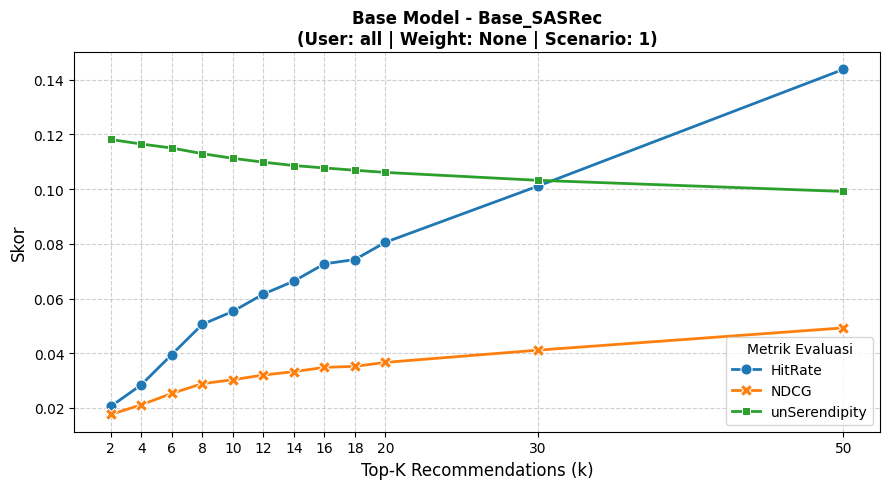

In [7]:
plot_single_model_metrics(df_master, model_name='Base_SASRec', title='Base Model')

### scenario 2

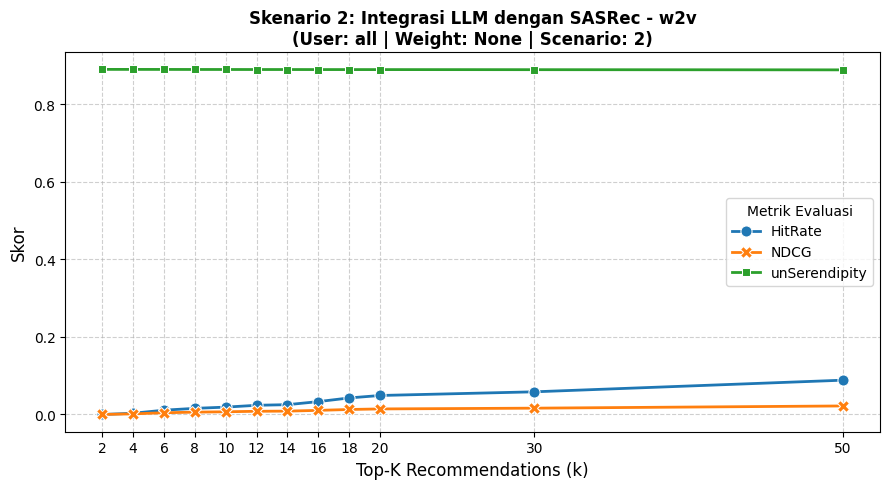

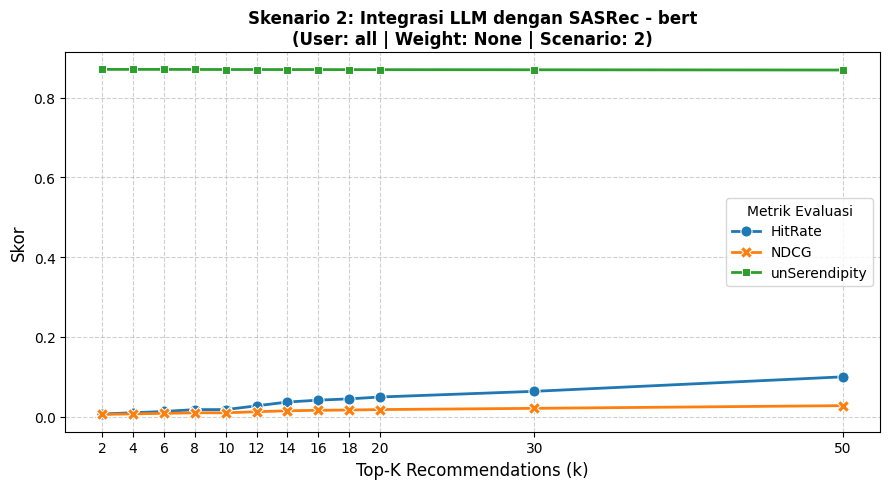

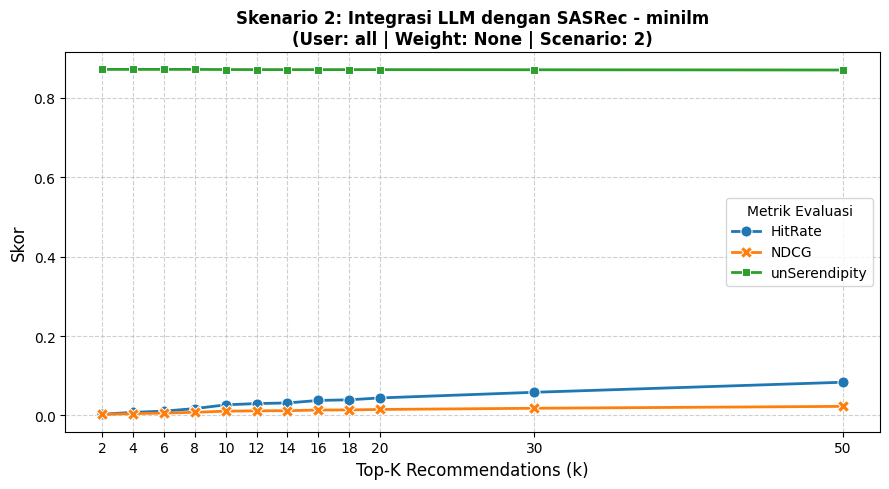

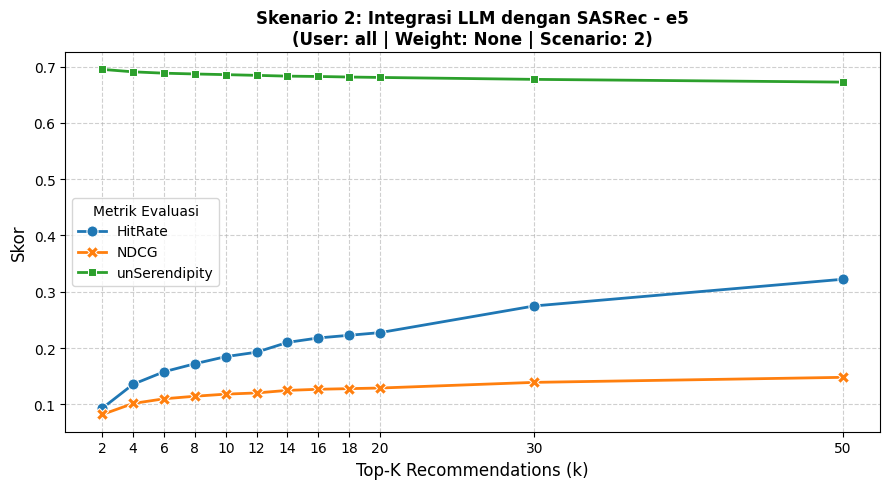

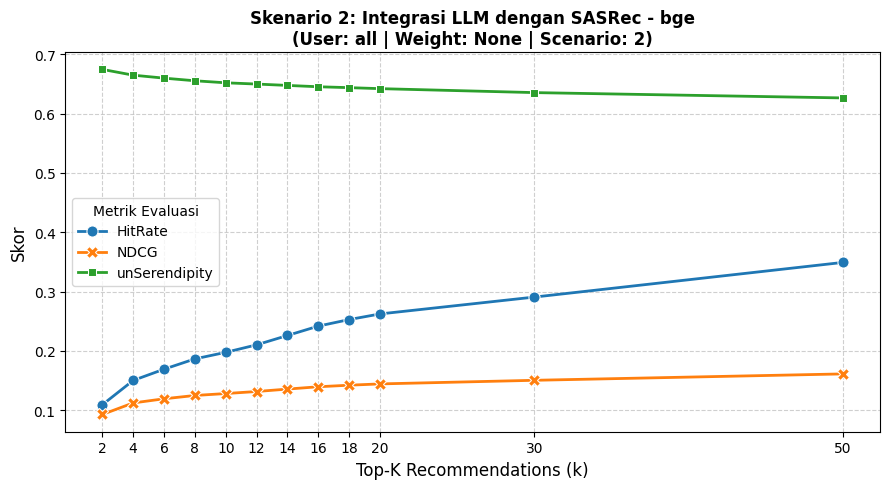

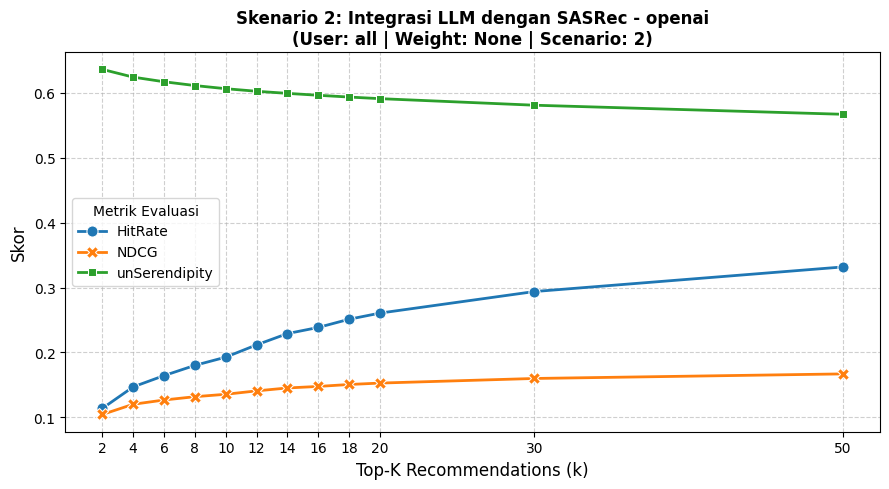

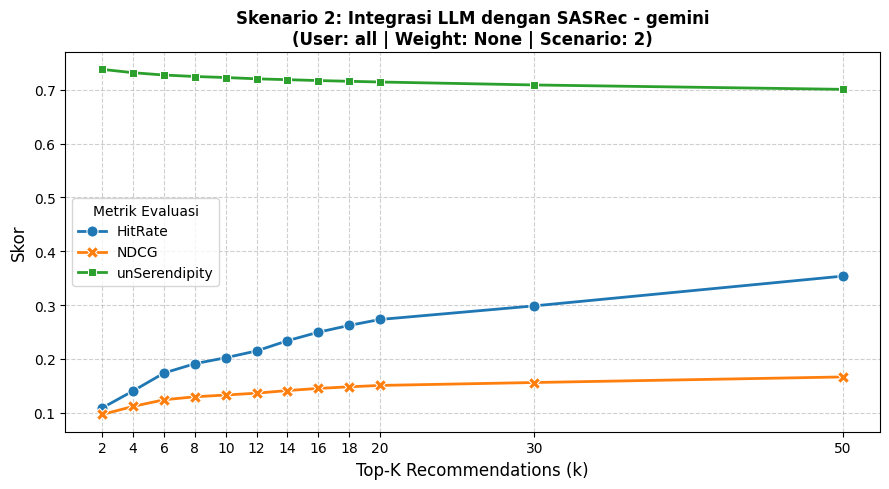

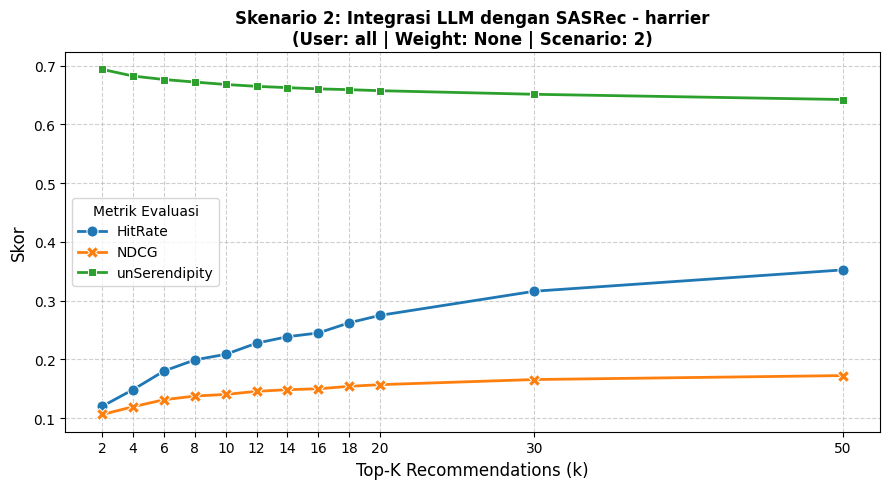

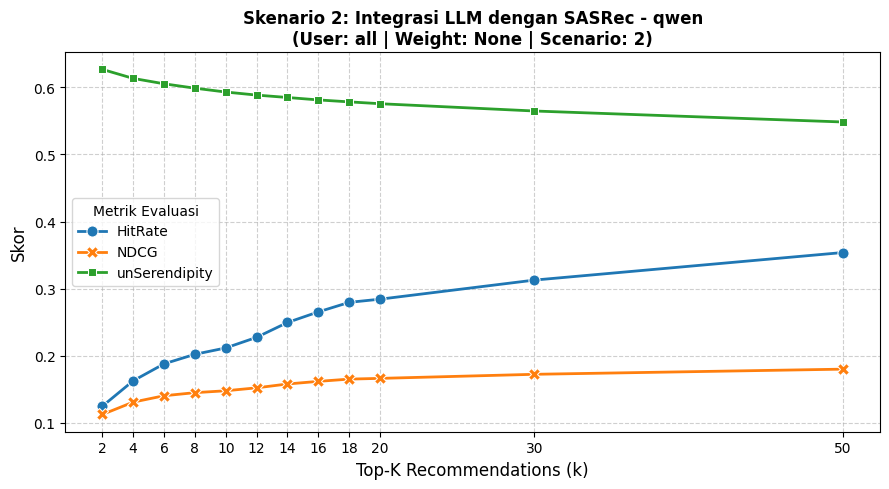

In [8]:
sasrecllm_models = [m for m in df_master_all_users['Model'].unique() if m != 'Base_SASRec']

for model_name in sasrecllm_models:
    plot_single_model_metrics(df_master_all_users, model_name=model_name, train_scenario='2', title='Skenario 2: Integrasi LLM dengan SASRec')

# plot_weight_comparison

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_weight_comparison(df, model_name, user_type='all', train_scenario=3):
    model_mask = df['Model'].astype(str).str.strip() == model_name
    user_mask = df['User_Type'].astype(str).str.strip() == user_type
    scenario_mask = pd.to_numeric(df['Train_Scenario'], errors='coerce') == float(train_scenario)
    
    df_filtered = df[model_mask & user_mask & scenario_mask].copy()
    
    df_filtered['Weight_Profile'] = df_filtered['Weight_Profile'].fillna('None')
    
    if df_filtered.empty:
        print(f"Data tidak ditemukan untuk Model: {model_name}, Skenario: {train_scenario}")
        return
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['HitRate', 'NDCG', 'unSerendipity']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for i, metric in enumerate(metrics):
        sns.lineplot(
            data=df_filtered,
            x='k',
            y=metric,
            hue='Weight_Profile',  # Membedakan warna berdasarkan weight
            style='Weight_Profile', # Membedakan bentuk garis/marker berdasarkan weight
            markers=True,
            dashes=False,
            linewidth=2,
            markersize=8,
            ax=axes[i],            # Menempatkan grafik di urutan yang tepat
            errorbar=None          # Mencegah bayangan jika ada duplikasi tak terduga
        )
        
        # Merapikan tampilan masing-masing subplot
        axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold', color=colors[i])
        axes[i].set_xlabel('Top-K Recommendations (k)', fontsize=12)
        axes[i].set_ylabel('Skor', fontsize=12)
        axes[i].set_xticks(df_filtered['k'].unique())
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
        # Pindahkan legend agar tidak menutupi garis
        axes[i].legend(title="Weight Profile")

    fig.suptitle(
        f' Weight Profile Effect - Model: {model_name}\n(User: {user_type}', 
        fontsize=16, 
        fontweight='bold', 
        y=1.05
    )
    
    plt.tight_layout()
    plt.show()

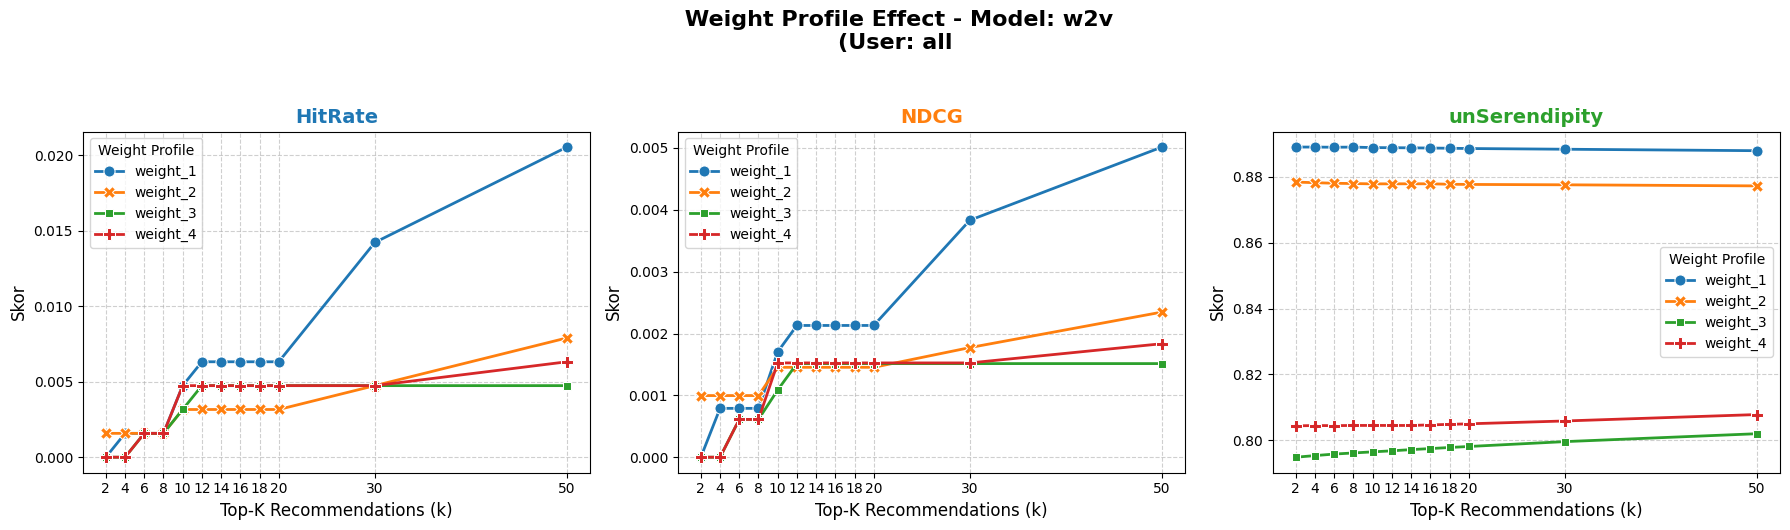

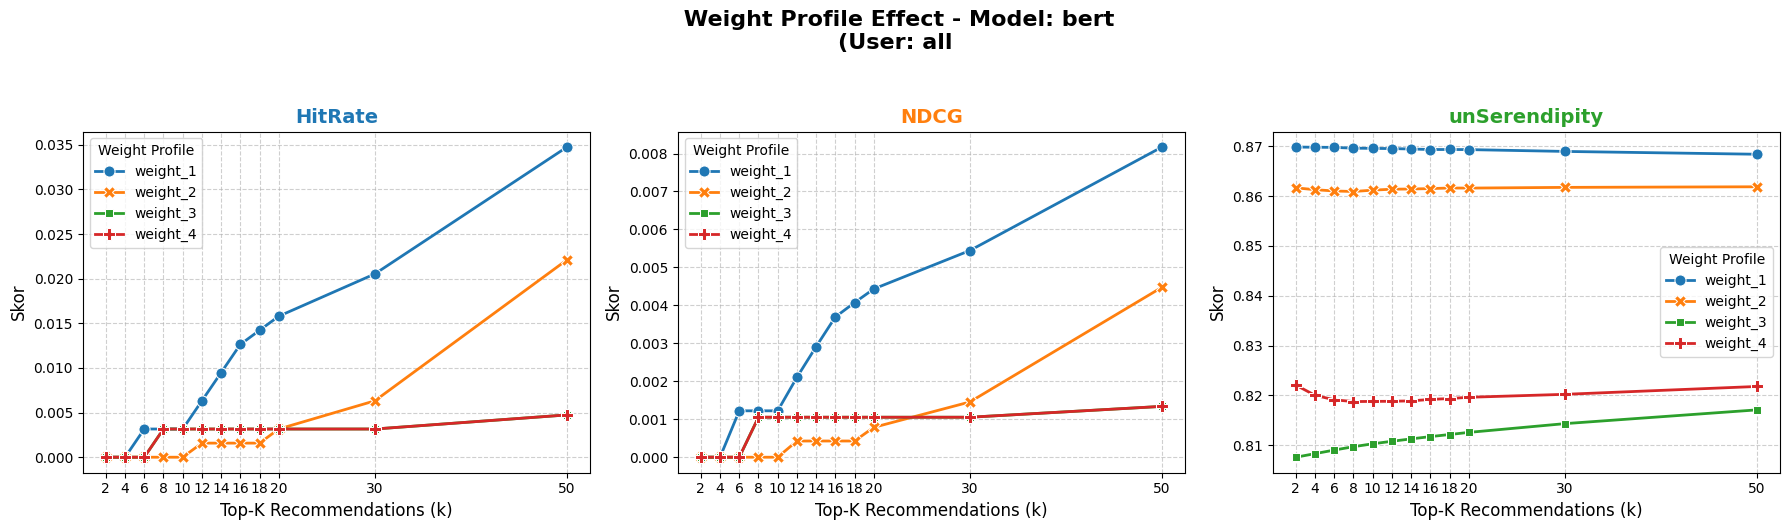

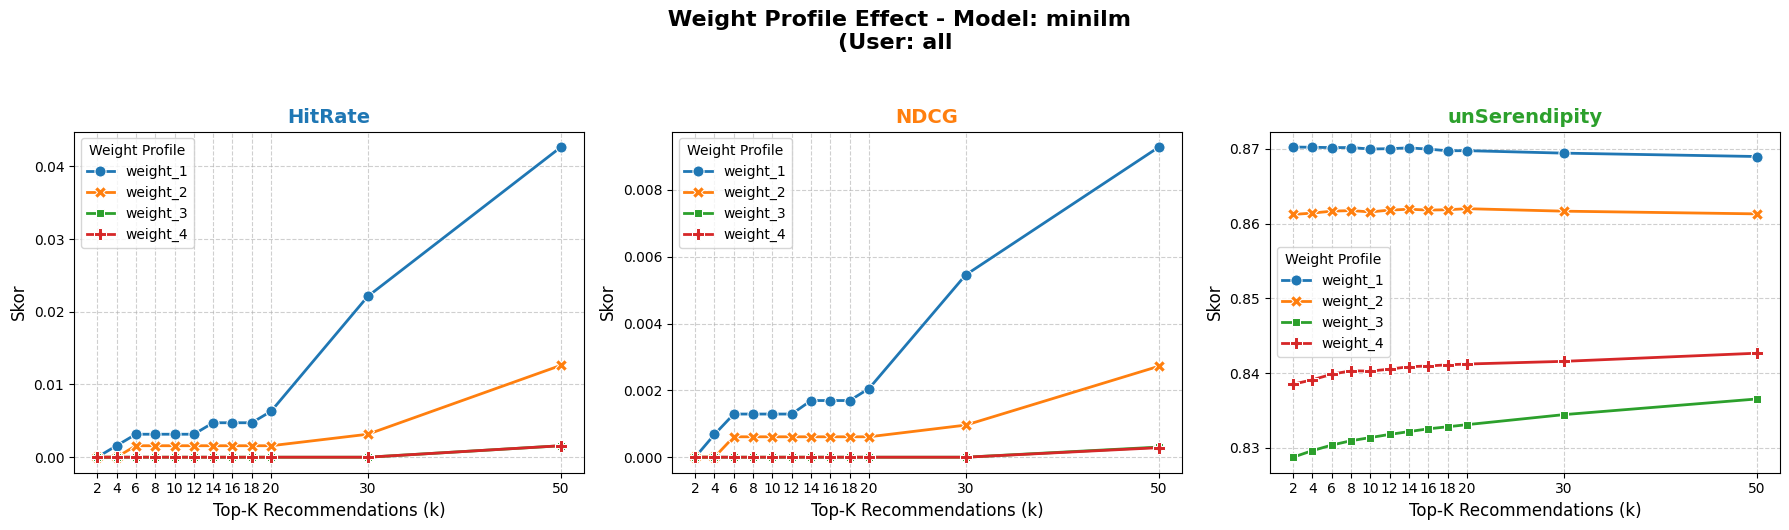

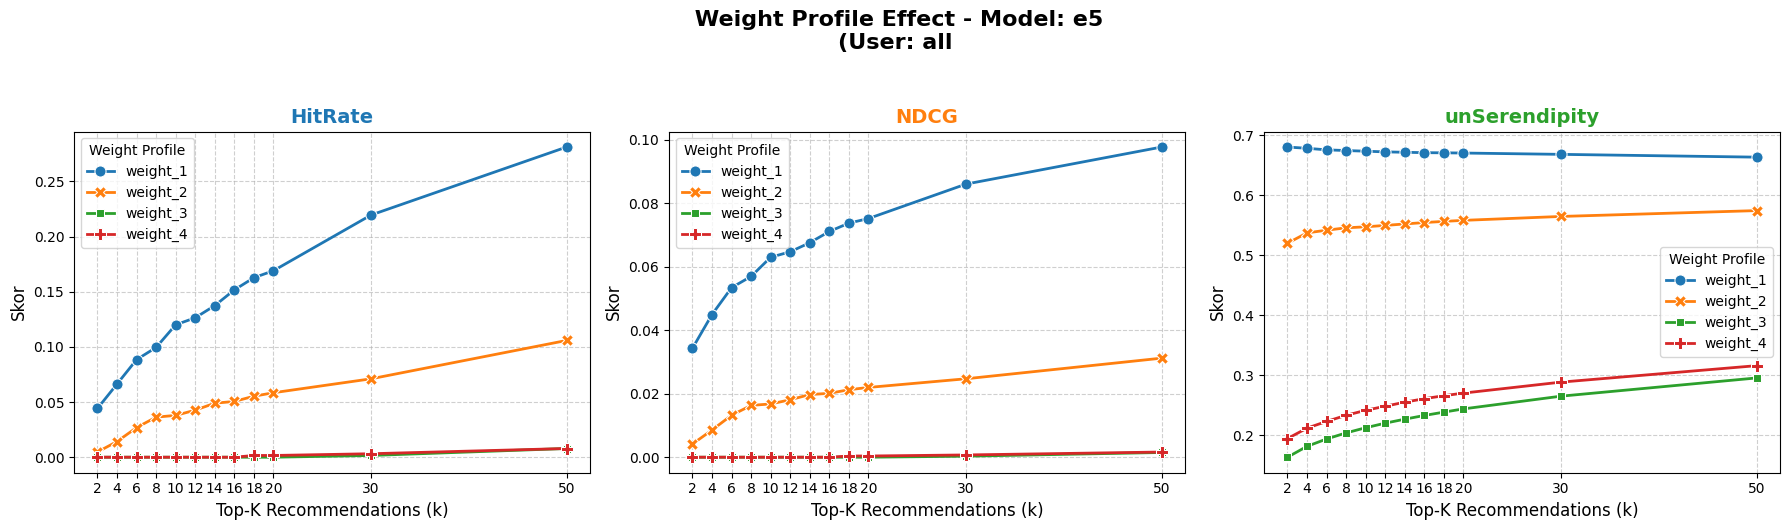

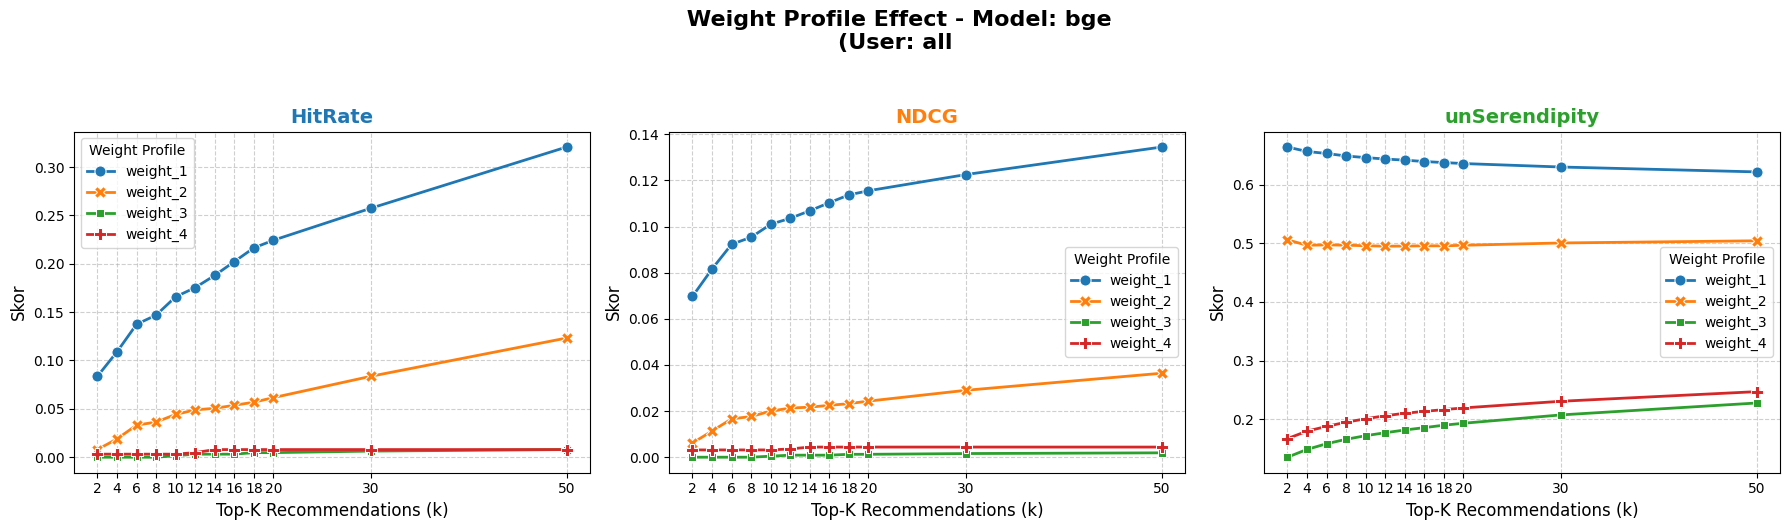

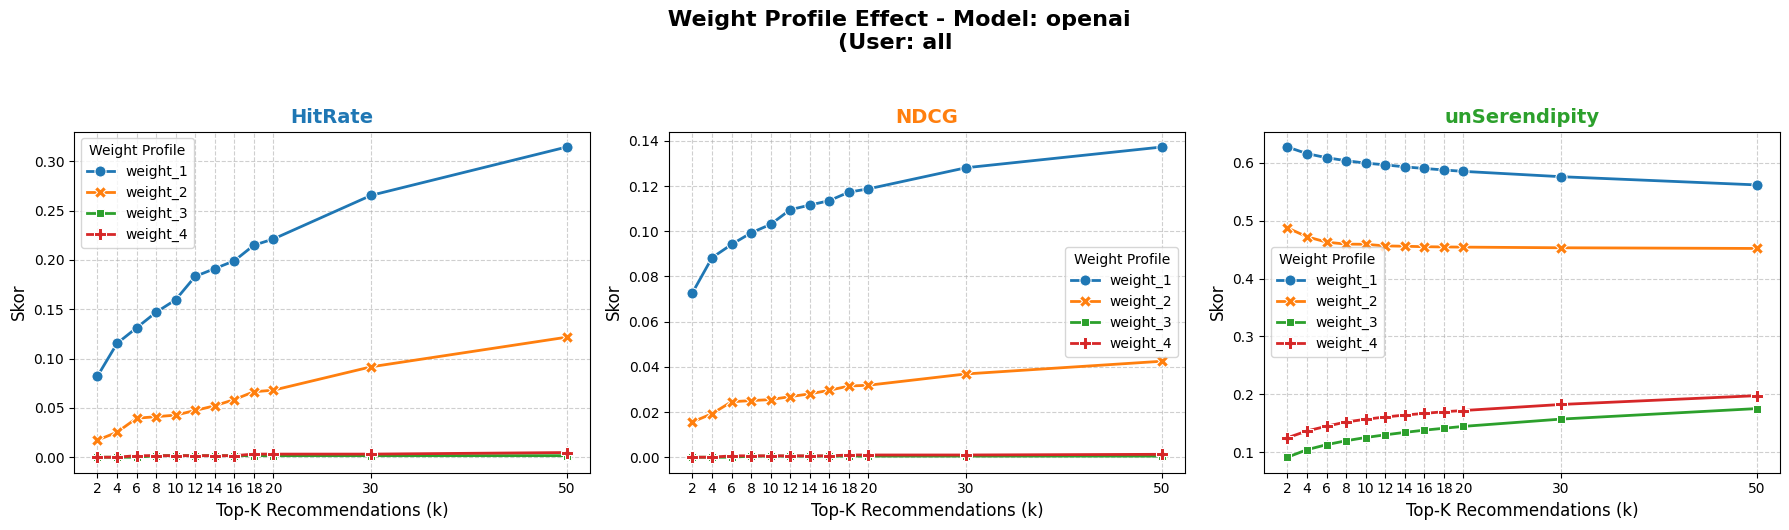

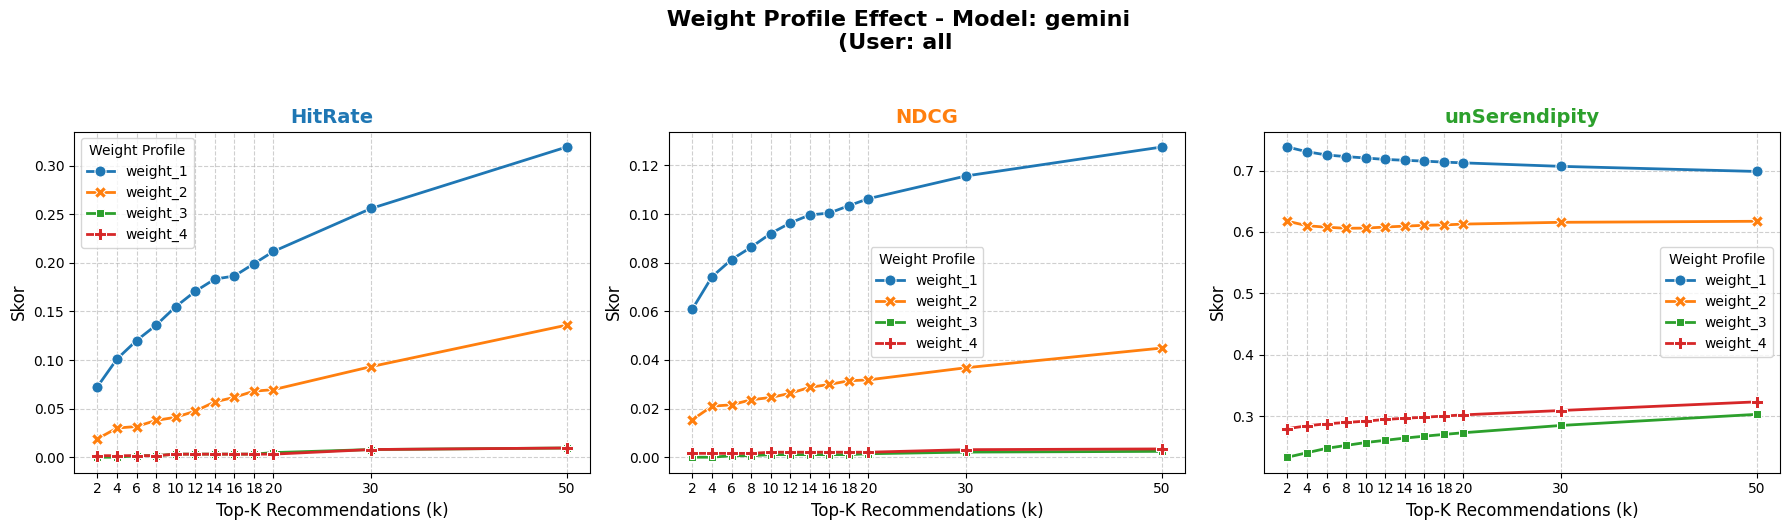

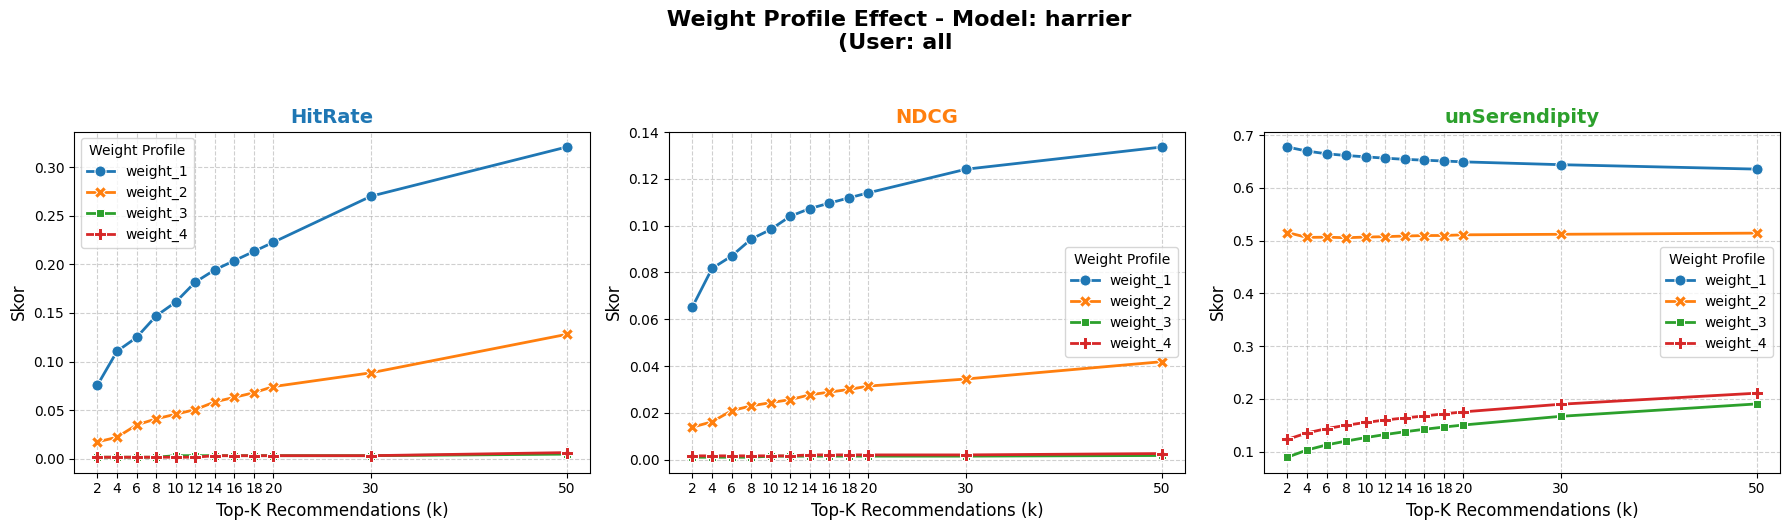

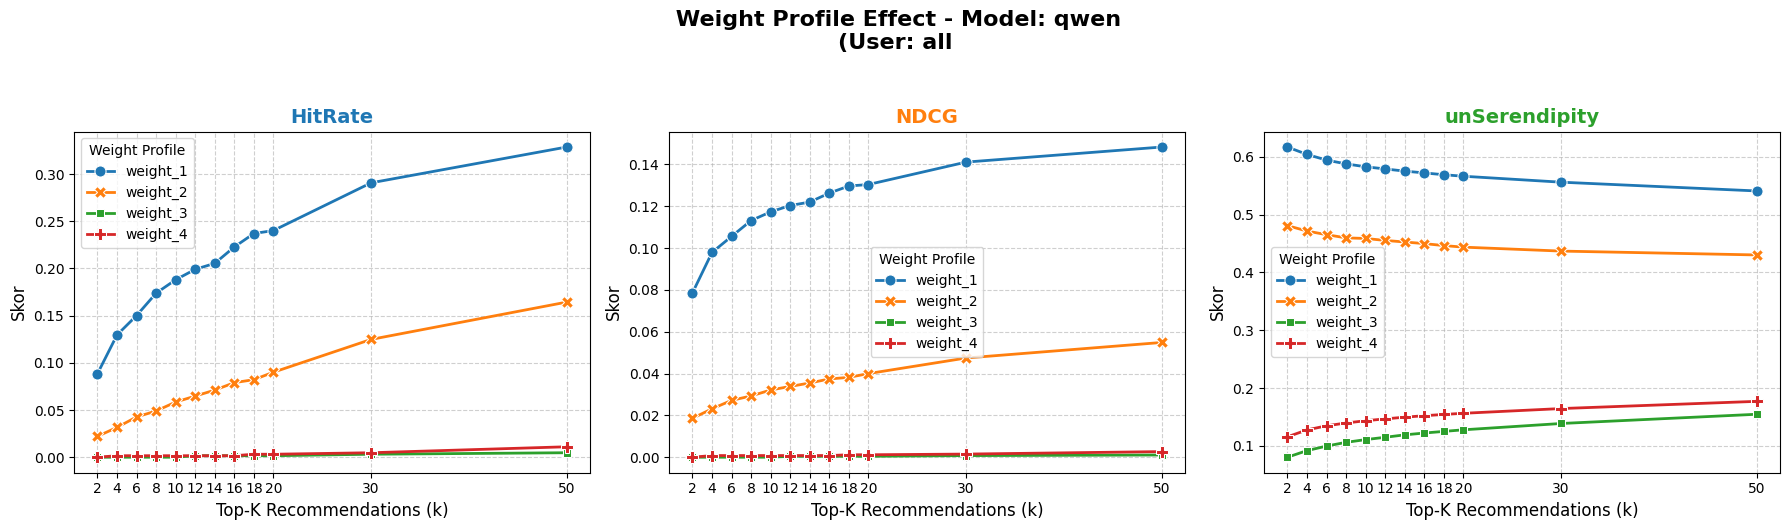

In [12]:
sog_models = [m for m in df_master_all_users['Model'].unique() if m != 'Base_SASRec']

for model_name in sog_models:
    plot_weight_comparison(df_master_all_users, model_name=model_name)

# plot_metric_competition

In [13]:
def plot_metric_competition(df, metric_to_plot, title, train_scenario=2, base_model='Base_SASRec', user_type='all'):
    df_filtered = df[
        (
            (df['Train_Scenario'] == train_scenario) | 
            (df['Model'] == base_model)
        ) &
        (df['User_Type'] == user_type)
    ].copy()

    if df_filtered.empty:
        print(f"Data kosong untuk Skenario {train_scenario} dan Base Model {base_model}")
        return
    
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=df_filtered, 
        x='k', y=metric_to_plot, 
        hue='Model', 
        style='Model', 
        markers=True, dashes=False, linewidth=2, markersize=8
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel(f'Skor {metric_to_plot}', fontsize=12)
    plt.xticks(df['k'].unique())
    
    # Pindahkan legenda ke luar grafik agar tidak menabrak garis
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variasi Model")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

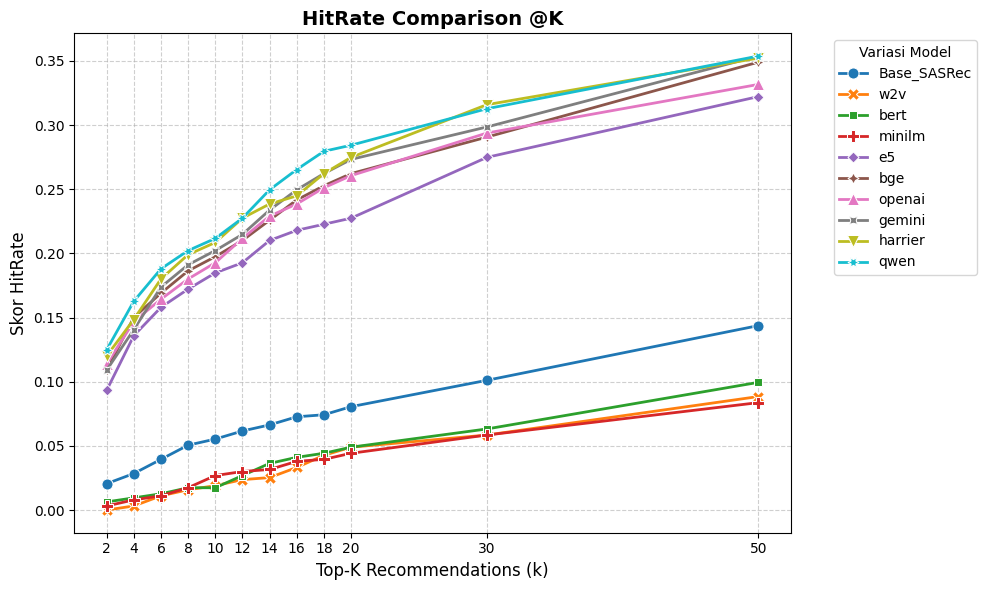

In [14]:
plot_metric_competition(df_master_all_users, 'HitRate', 'HitRate Comparison @K')

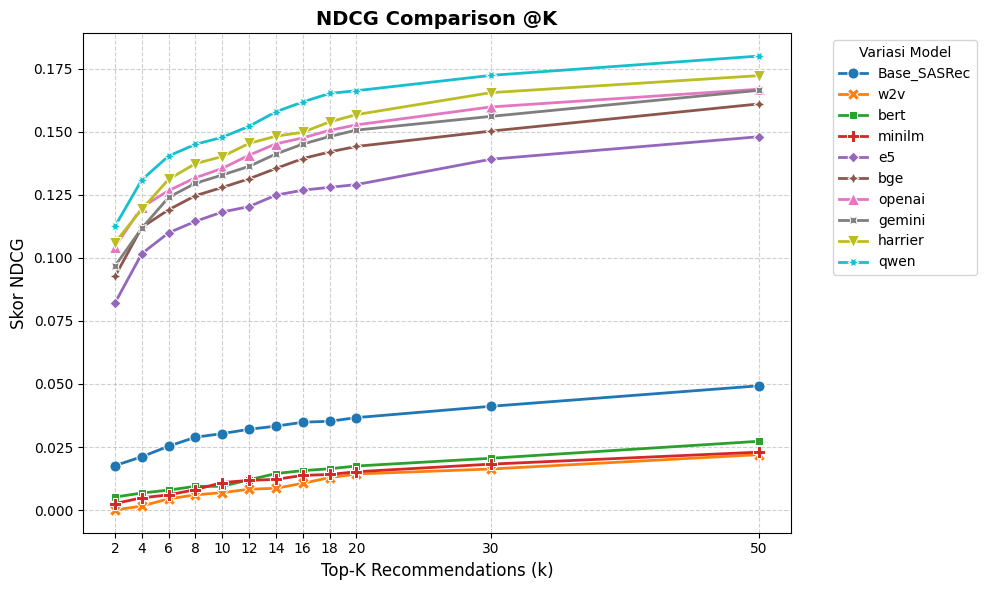

In [15]:
plot_metric_competition(df_master_all_users, 'NDCG', 'NDCG Comparison @K')

In [58]:
def plot_competition_melted(df, title="Accuracy (HitRate & NDCG)", train_scenario=2, base_model='Base_SASRec', user_type='all'):
    # 1. Filter the dataframe
    df_filtered = df[
        (
            (df['Train_Scenario'] == train_scenario) | 
            (df['Model'] == base_model)
        ) &
        (df['User_Type'] == user_type)
    ].copy()

    if df_filtered.empty:
        print(f"Data kosong untuk Skenario {train_scenario} dan Base Model {base_model}")
        return
    
    # 2. Gunakan melt() untuk menggabungkan HitRate dan NDCG
    df_melt = df_filtered.melt(
        id_vars=['k', 'Model'],          # Kolom yang dipertahankan sebagai identifier
        value_vars=['HitRate', 'NDCG'],  # Kolom metrik yang dilebur
        var_name='Metrik', 
        value_name='Skor'
    )
    
    # 3. Buat Plot
    plt.figure(figsize=(12, 7)) # Sedikit diperlebar agar legend muat
    
    sns.lineplot(
        data=df_melt, 
        x='k', 
        y='Skor', 
        hue='Model',       # Warna garis merepresentasikan Model
        style='Metrik',    # Bentuk garis (Solid/Dashed) merepresentasikan HitRate vs NDCG
        markers=True, 
        dashes=True,       # Wajib True agar bisa membedakan HitRate & NDCG dari gaya garisnya
        linewidth=2, 
        markersize=8,
        errorbar=None
    )
    
    # 4. Format Tampilan
    plt.title(f"{title}\n(Skenario: {train_scenario} | Base: {base_model} | User: {user_type})", 
              fontsize=14, fontweight='bold')
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.xticks(df_filtered['k'].unique())
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Pindahkan legenda ke luar
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Model & Metrik")
    plt.tight_layout()
    plt.show()

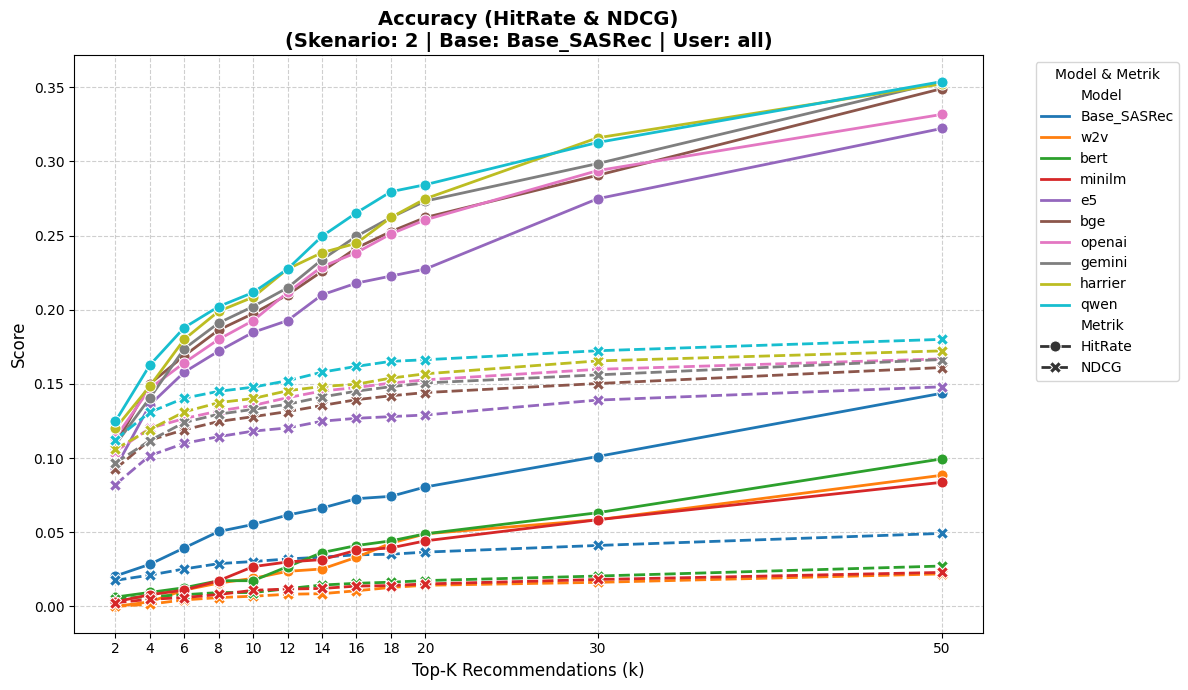

In [59]:
plot_competition_melted(df_master_all_users, train_scenario=2, base_model='Base_SASRec', user_type='all')

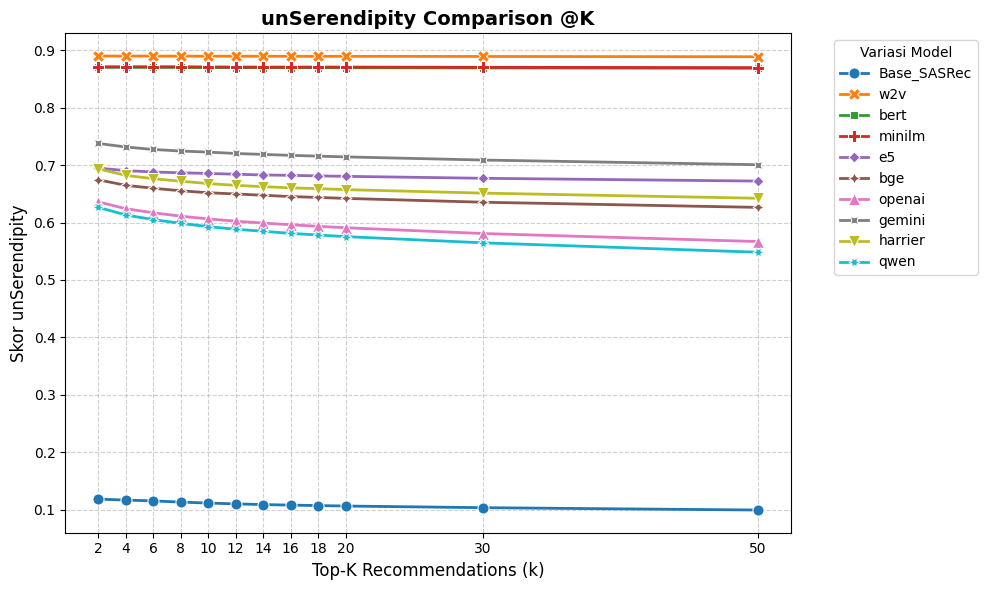

In [16]:
plot_metric_competition(df_master_all_users, 'unSerendipity', 'unSerendipity Comparison @K')

# plot_comparison_at_k

In [17]:
def plot_comparison_at_k(df, k_val=10, train_scenario=2, base_model='Base_SASRec', user_type='all'):
    df_k = df[
        (df['k'] == k_val) & 
        (df['User_Type'] == user_type) &
        (
            (df['Train_Scenario'] == train_scenario) | 
            (df['Model'] == base_model)
        )
    ].copy()

    if df_k.empty:
        print(f"Data untuk K={k_val} tidak ditemukan!")
        return
        
    df_melt = df_k.melt(
        id_vars=['Model'],
        value_vars=['HitRate', 'NDCG', 'unSerendipity'],
        var_name='Metrik',
        value_name='Skor'
    )
    
    plt.figure(figsize=(14, 6))
    
    barplot = sns.barplot(
        data=df_melt,
        x='Model', y='Skor', hue='Metrik',
        palette=['#1f77b4', '#ff7f0e', '#2ca02c']
    )
    
    plt.title(f'Performance Comparison @{k_val}', fontsize=16, fontweight='bold')
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    
    plt.xticks(rotation=30, ha='right')
    
    # Tambahkan angka di atas setiap batang
    for p in barplot.patches:
        val = p.get_height()
        if val > 0: # Cek jika nilai tidak NaN/0
            barplot.annotate(f'{val:.4f}',
                            (p.get_x() + p.get_width() / 2., val),
                            ha = 'center', va = 'center',
                            xytext = (0, 8),
                            textcoords = 'offset points',
                            fontsize=8, rotation=90) # Angka dirotasi agar tidak saling bertumpuk

    plt.legend(title='Metrik')
    plt.tight_layout()
    plt.show()

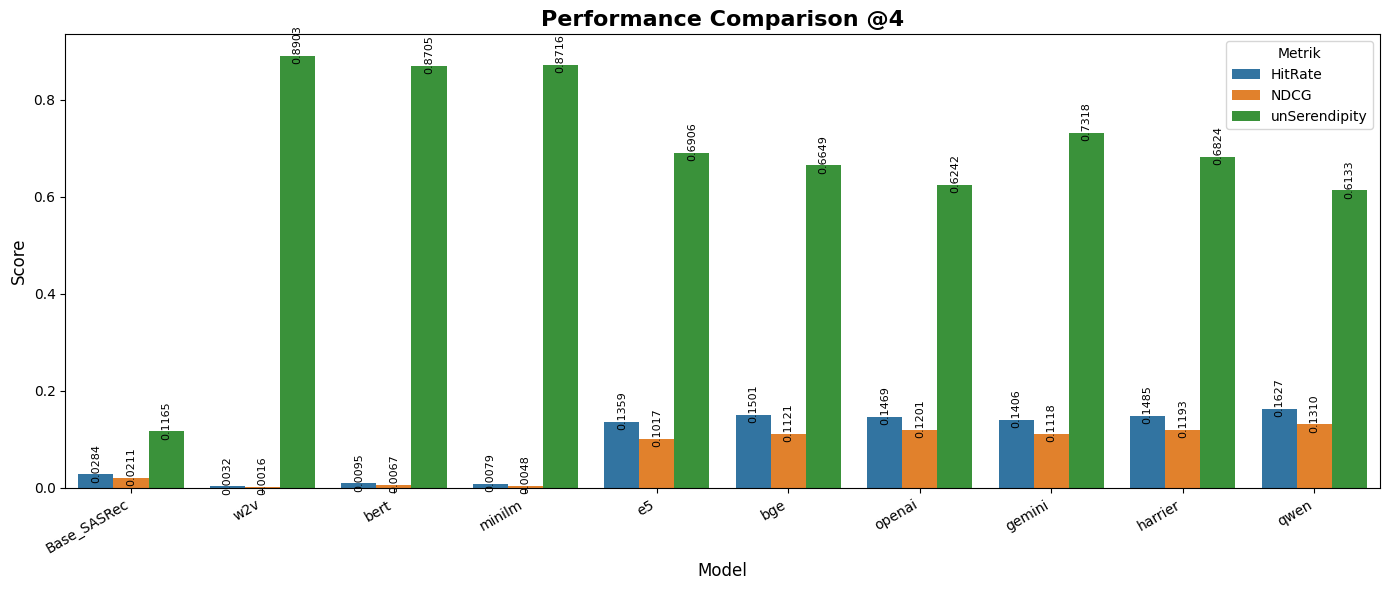

In [18]:
plot_comparison_at_k(df_master_all_users, k_val=4)

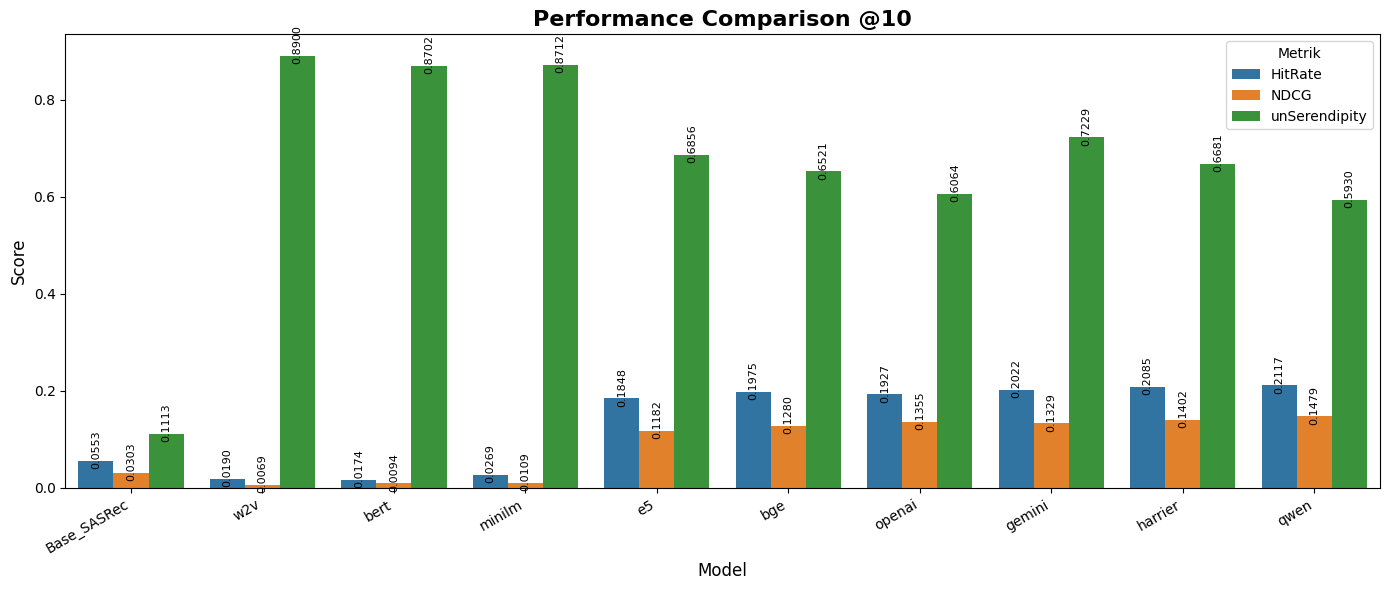

In [19]:
plot_comparison_at_k(df_master_all_users, k_val=10)

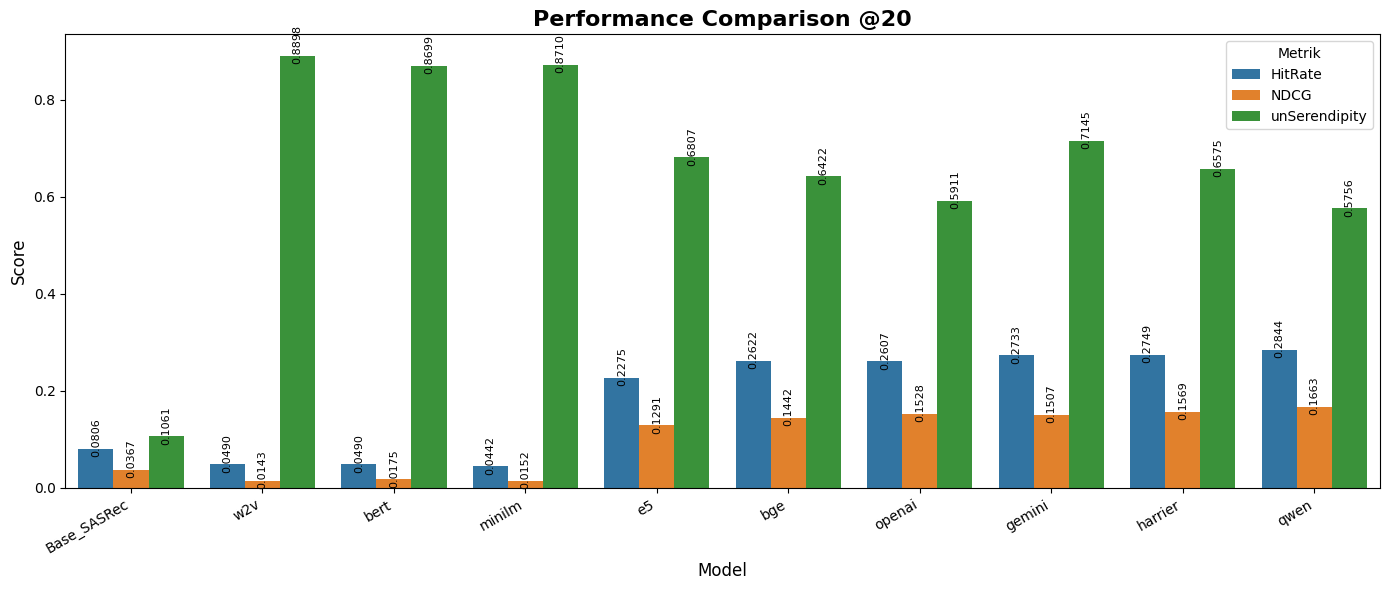

In [20]:
plot_comparison_at_k(df_master_all_users, k_val=20)

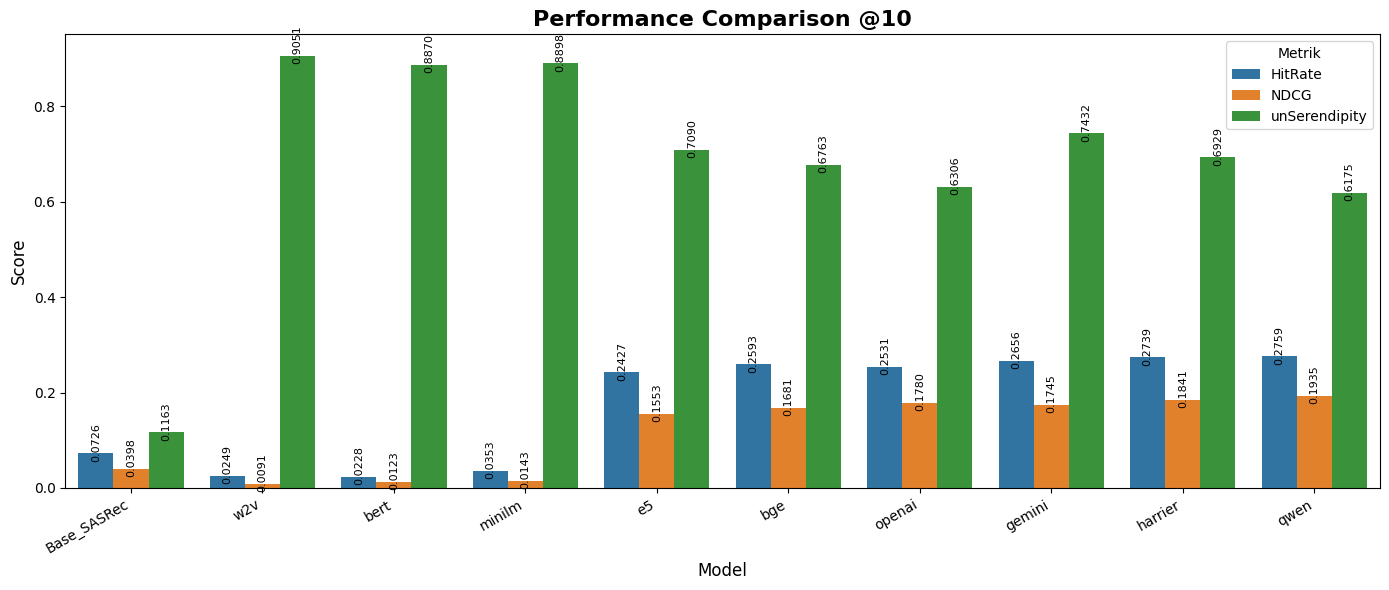

In [21]:
plot_comparison_at_k(df_master, k_val=10, user_type='warm')

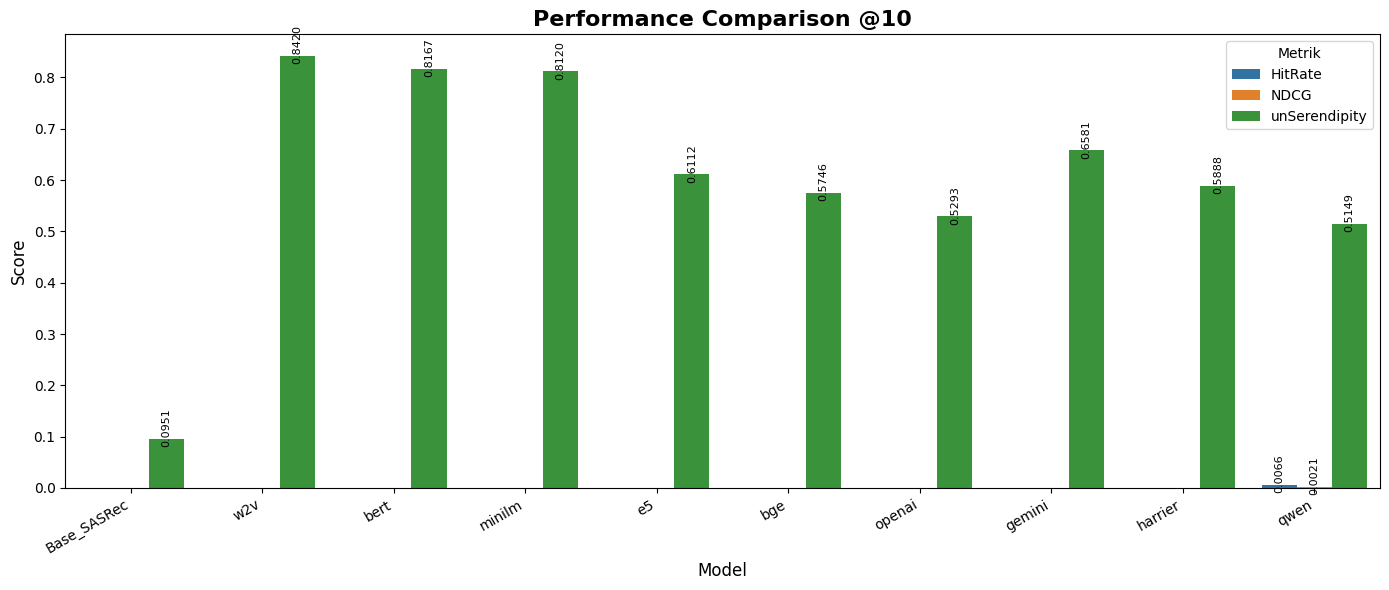

In [22]:
plot_comparison_at_k(df_master, k_val=10, user_type='cold')

# trade off

Scatter Plot: Trade-off Frontier (Akurasi vs Serendipity)
Grafik ini memetakan titik temu terbaik antara akurasi yang tidak terlalu hancur, namun kebaruannya tinggi.

In [23]:
def plot_tradeoff_scatter_2(df, k_val=10, user_type='all'):
    plt.figure(figsize=(10, 6))
    
    # Buat kolom Base_Model secara otomatis jika belum ada
    if 'Base_Model' not in df.columns:
        df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])
        
    # Filter data
    if 'User_Type' in df.columns:
        df_k = df[(df['User_Type'] == user_type) & (df['k'] == k_val)].copy()
    else:
        df_k = df[df['k'] == k_val].copy()
        
    if df_k.empty:
        print(f"Data tidak ditemukan untuk k={k_val} dan user_type='{user_type}'!")
        return

    # Scatter Plot
    scatter = sns.scatterplot(
        data=df_k,
        x='unSerendipity',
        y='HitRate',
        hue='Model',
        style='Base_Model',
        s=200,
        palette='tab20',
        alpha=0.8,
    )
    
    for i in range(df_k.shape[0]):
        label_text = df_k['Model'].iloc[i]
        
        plt.text(
            df_k['unSerendipity'].iloc[i],
            df_k['HitRate'].iloc[i] + 0.0015,
            label_text,
            horizontalalignment='center',
            fontsize=8, color='black', weight='semibold'
        )

    plt.title(f'Trade-off Frontier: HitRate vs unSerendipity (Top-{k_val}) {"All User" if user_type == "all" else user_type}', fontsize=14, fontweight='bold')
    plt.xlabel('unSerendipity', fontsize=12, color='darkred')
    plt.ylabel('HitRate', fontsize=12, color='darkgreen')
    
    plt.annotate('Balanced Area', 
                xy=(0.05, 0.9), xycoords='axes fraction',
                fontsize=10, color='green', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="green", alpha=0.3))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#### scenario 2

In [24]:
scenario_2 = df_master[(df_master['Train_Scenario'] == 2)]
scenario_2

,User_Type,Weight_Profile,Model,k,HitRate,NDCG,unSerendipity,Train_Scenario,trainable
36,all,NaN,w2v,2,0.000000,0.000000,0.890305,2.0,True
37,all,NaN,w2v,4,0.003160,0.001580,0.890255,2.0,True
38,all,NaN,w2v,6,0.011058,0.004442,0.890199,2.0,True
39,all,NaN,w2v,8,0.015798,0.005993,0.890085,2.0,True
40,all,NaN,w2v,10,0.018957,0.006926,0.890043,2.0,True
...,...,...,...,...,...,...,...,...,...
355,cold,NaN,qwen,16,0.006623,0.002089,0.504356,2.0,True
356,cold,NaN,qwen,18,0.006623,0.002089,0.501263,2.0,True
357,cold,NaN,qwen,20,0.006623,0.002089,0.499086,2.0,True
358,cold,NaN,qwen,30,0.006623,0.002089,0.488728,2.0,True


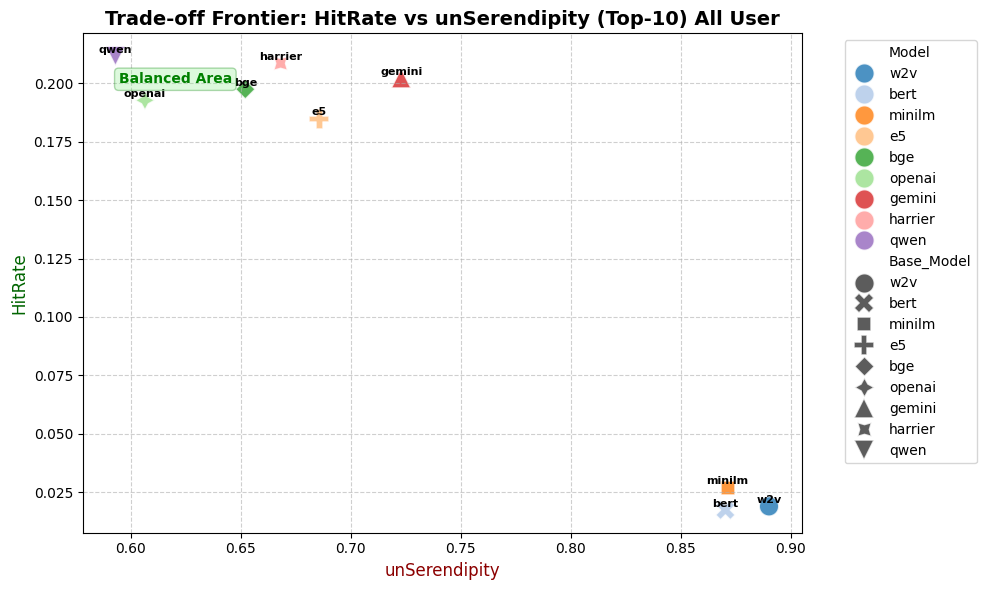

In [25]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='all')

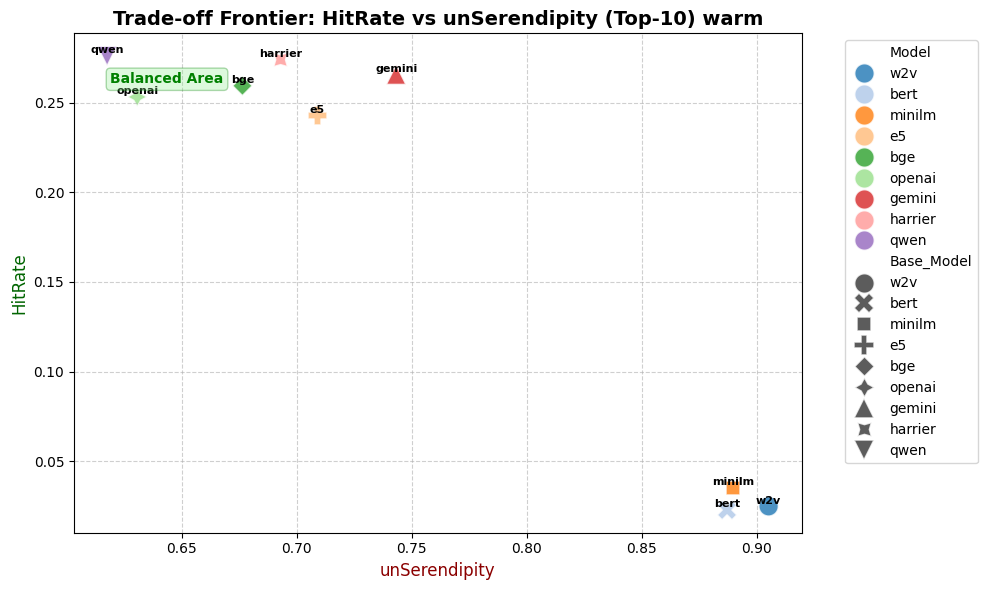

In [26]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='warm')

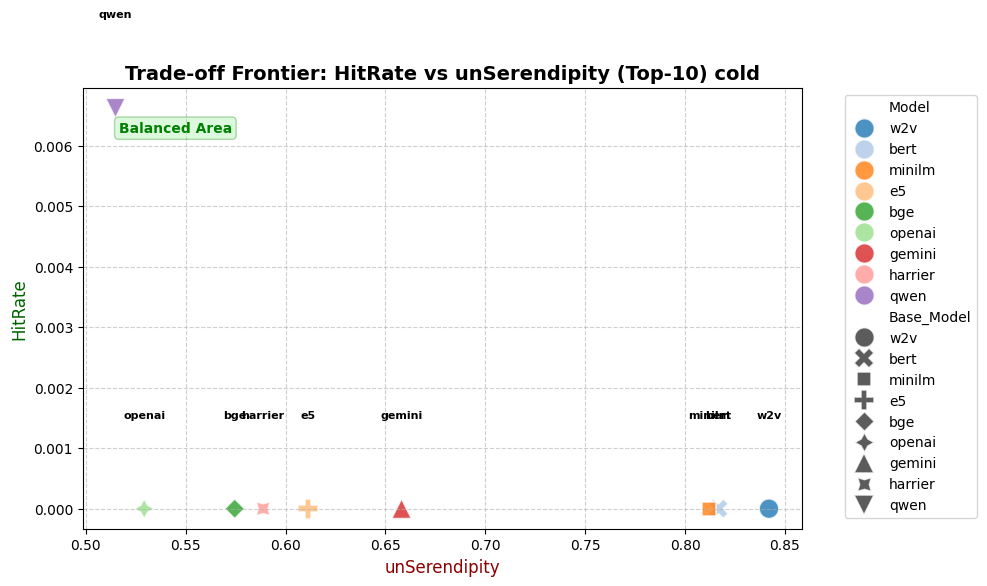

In [27]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='cold')

#### scenario 3

In [28]:
def plot_tradeoff_scatter_3(df, k_val=10, user_type='all'):
    plt.figure(figsize=(10, 6))
    
    # Buat kolom Base_Model secara otomatis jika belum ada
    if 'Base_Model' not in df.columns:
        df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])
        
    # Filter data
    if 'User_Type' in df.columns:
        df_k = df[(df['User_Type'] == user_type) & (df['k'] == k_val)].copy()
    else:
        df_k = df[df['k'] == k_val].copy()
        
    if df_k.empty:
        print(f"Data tidak ditemukan untuk k={k_val} dan user_type='{user_type}'!")
        return

    # Scatter Plot
    scatter = sns.scatterplot(
        data=df_k,
        x='unSerendipity',
        y='HitRate',
        hue='Model',
        style='Base_Model',
        s=200,
        palette='tab20',
        alpha=0.8
    )
    
    for i in range(df_k.shape[0]):
        label_text = df_k['Weight_Profile'].iloc[i]
        
        plt.text(
            df_k['unSerendipity'].iloc[i],
            df_k['HitRate'].iloc[i] + 0.0015,
            label_text,
            horizontalalignment='center',
            fontsize=8, color='black', weight='semibold'
        )

    plt.title(f'HitRate vs unSerendipity (Top-{k_val}) - User Type: {user_type}', fontsize=14, fontweight='bold')
    plt.xlabel('unSerendipity', fontsize=12, color='darkred')
    plt.ylabel('HitRate', fontsize=12, color='darkgreen')
    
    plt.annotate('Balanced Area', 
                xy=(0.05, 0.9), xycoords='axes fraction',
                fontsize=10, color='green', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="green", alpha=0.3))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [29]:
scenario_3 = df_master[(df_master['Train_Scenario'] == 3)]
scenario_3

,User_Type,Weight_Profile,Model,k,HitRate,NDCG,unSerendipity,Train_Scenario,trainable
360,all,weight_1,w2v,2,0.000000,0.000000,0.889101,3.0,True
361,all,weight_1,w2v,4,0.001580,0.000790,0.889091,3.0,True
362,all,weight_1,w2v,6,0.001580,0.000790,0.889039,3.0,True
363,all,weight_1,w2v,8,0.001580,0.000790,0.889084,3.0,True
364,all,weight_1,w2v,10,0.004739,0.001703,0.888933,3.0,True
...,...,...,...,...,...,...,...,...,...
1651,cold,weight_4,qwen,16,0.000000,0.000000,0.139235,3.0,True
1652,cold,weight_4,qwen,18,0.000000,0.000000,0.140632,3.0,True
1653,cold,weight_4,qwen,20,0.000000,0.000000,0.142474,3.0,True
1654,cold,weight_4,qwen,30,0.000000,0.000000,0.149175,3.0,True


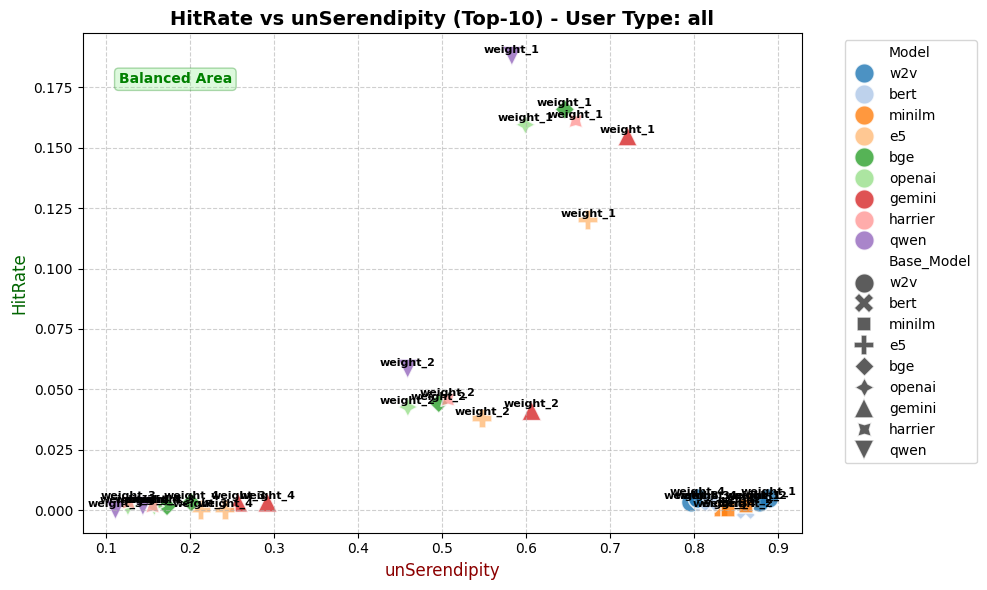

In [30]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='all')

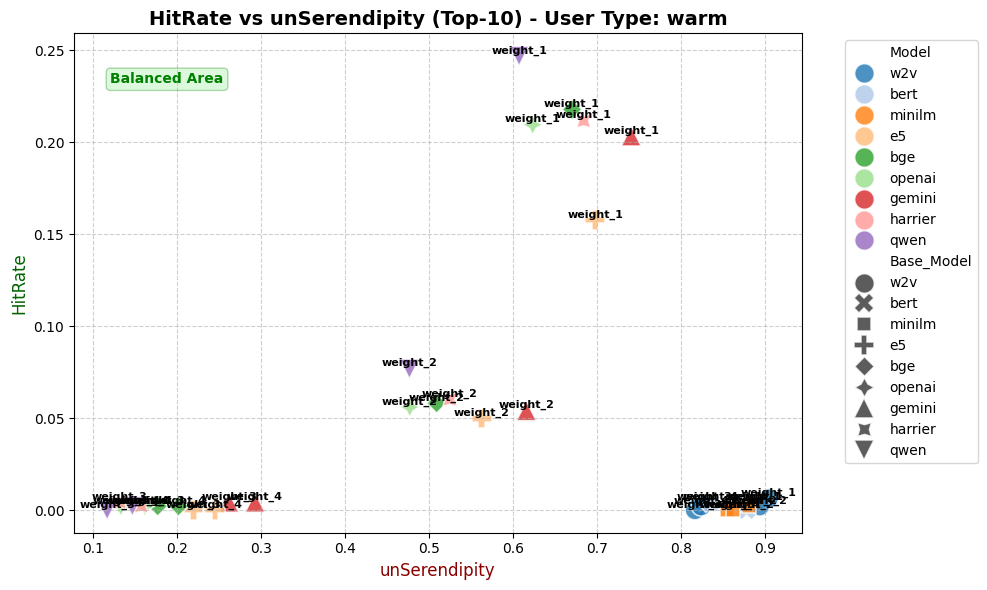

In [31]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='warm')

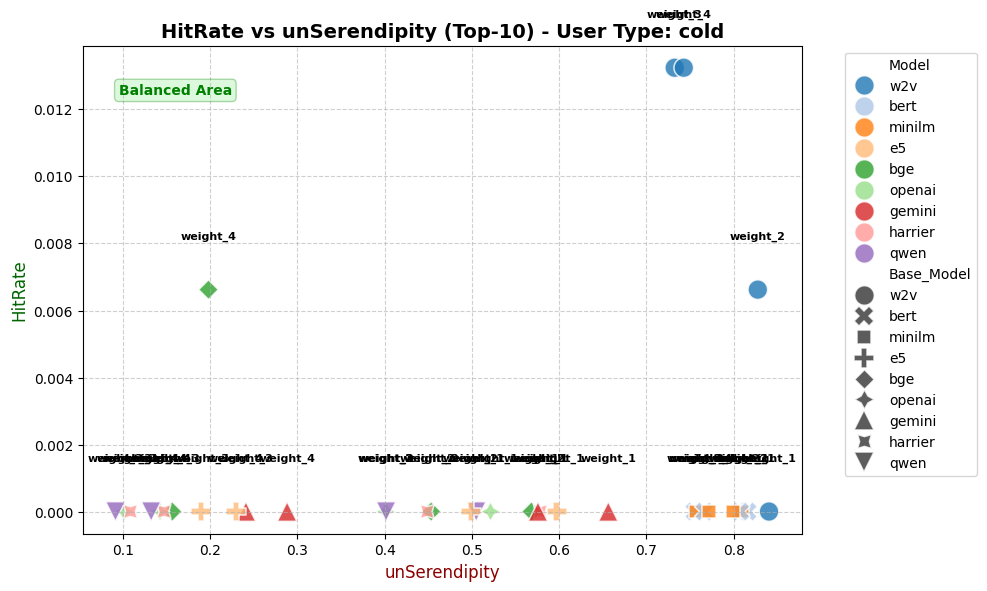

In [32]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='cold')

# cold vs warm

Grafik ini akan membuktikan bahwa skenario SOG re-ranking memberikan impak yang berbeda terhadap pengguna baru (Cold) dibanding pengguna lama (Warm).

In [33]:
def plot_cold_vs_warm(df_full, metric='HitRate', k_val=10, weight_profile='None'):
    df_cw = df_full.copy()
    df_cw = df_cw.fillna('None')
    df_cw = df_cw[(df_cw['k'] == k_val) & (df_cw['User_Type'].isin([ 'all', 'warm', 'cold'])) & (df_cw['Weight_Profile'] == weight_profile)]

    if df_cw.empty:
        print("Data Cold/Warm tidak ditemukan!")
        return
        
    plt.figure(figsize=(14, 6))

    barplot = sns.barplot(
        data=df_cw,
        x='Model',
        y=metric,
        hue='User_Type',
        palette=['#9500ff','#f50c0c', '#4287f5'], # Warna (red, blue)
        errorbar=None
    )
    
    plt.title(f'{metric} Comparison on Cold vs Warm Users (Top-{k_val})', fontsize=14, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel(f'Skor {metric}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Tambahkan angka di atas bar
    for p in barplot.patches:
        height = p.get_height()
        if not np.isnan(height) and height >= 0:
            barplot.annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha = 'center', va = 'center',
                            xytext = (0, 8),
                            textcoords = 'offset points',
                            fontsize=9,
                            rotation=0)

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='User Type')
    plt.tight_layout()
    plt.show()

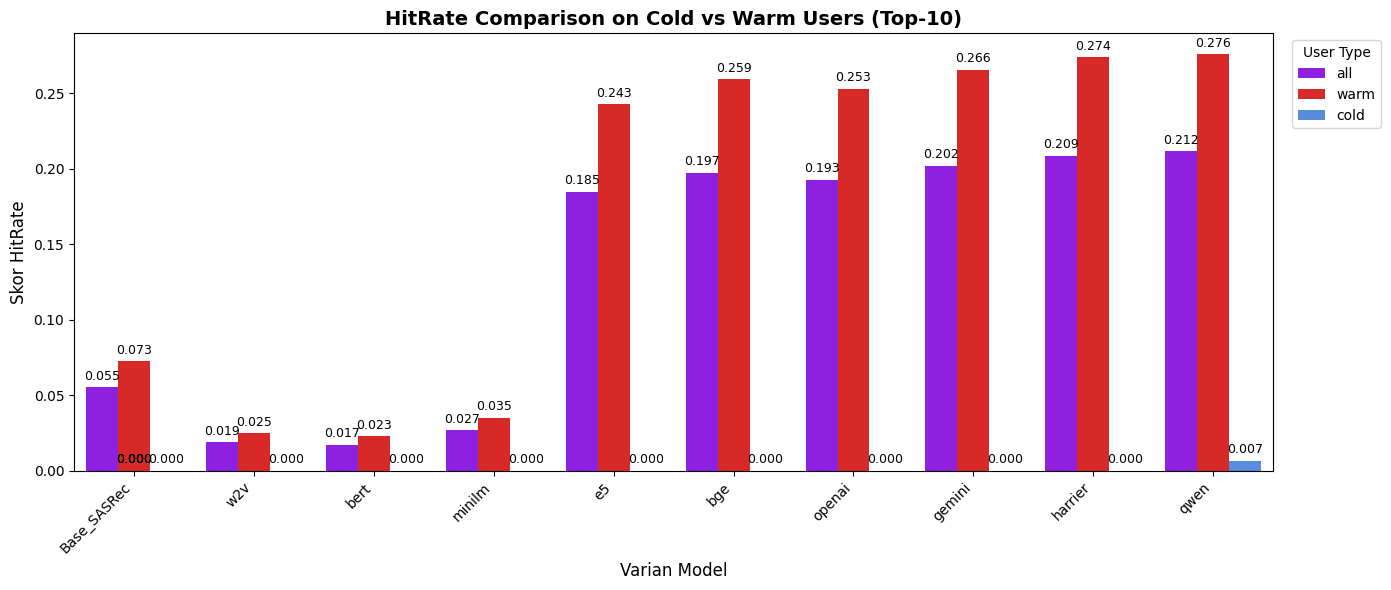

In [34]:
plot_cold_vs_warm(df_master, metric='HitRate', k_val=10)

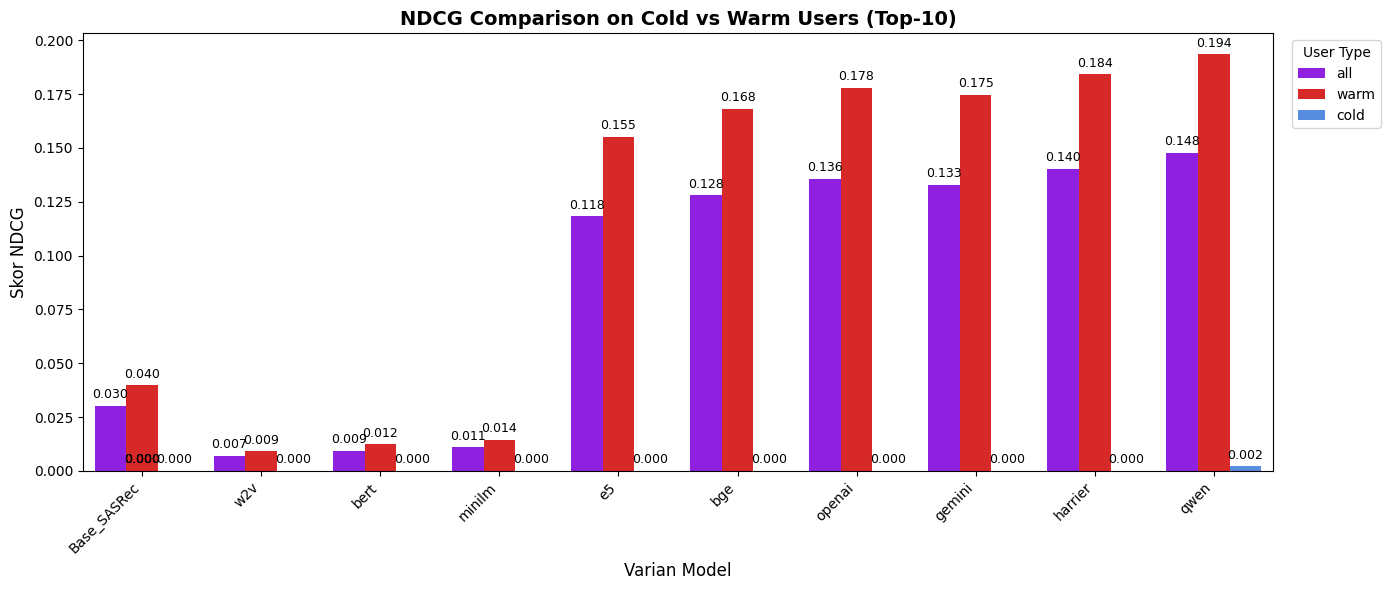

In [35]:

plot_cold_vs_warm(df_master, metric='NDCG', k_val=10)

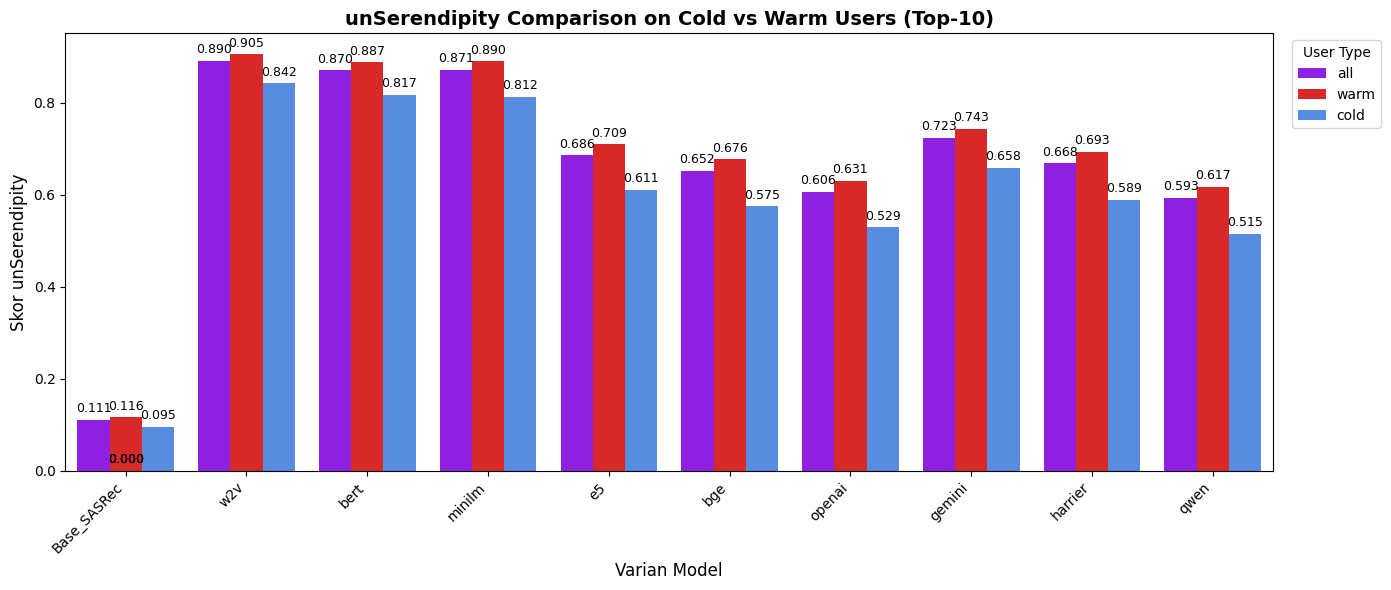

In [36]:

plot_cold_vs_warm(df_master, metric='unSerendipity', k_val=10)

In [60]:
def plot_cold_vs_warm_multi(df_full, k_val=10, weight_profile='None'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    metrics = ['HitRate', 'NDCG', 'unSerendipity']  # <- adjust if needed
    
    df_cw = df_full.copy()
    df_cw = df_cw.fillna('None')
    df_cw = df_cw[
        (df_cw['k'] == k_val) &
        (df_cw['User_Type'].isin(['all', 'warm', 'cold'])) &
        (df_cw['Weight_Profile'] == weight_profile)
    ]

    if df_cw.empty:
        print("Data Cold/Warm tidak ditemukan!")
        return

    # === CREATE SUBPLOTS ===
    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 6), sharex=True)

    palette = ['#9500ff', '#f50c0c', '#4287f5']

    for i, metric in enumerate(metrics):
        ax = axes[i]

        sns.barplot(
            data=df_cw,
            x='Model',
            y=metric,
            hue='User_Type',
            palette=palette,
            errorbar=None,
            ax=ax
        )

        ax.set_title(f'{metric}@{k_val}', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(metric)

        ax.tick_params(axis='x', rotation=45)

        # Annotate values
        for p in ax.patches:
            height = p.get_height()
            if not np.isnan(height) and height >= 0:
                ax.annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center',
                            xytext=(0, 6),
                            textcoords='offset points',
                            fontsize=8)

        # Remove duplicate legends
        if i != len(metrics) - 1:
            ax.get_legend().remove()

    # Put legend only once (right side)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, title='User Type',
               bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.suptitle(f'Performance Comparison (Cold vs Warm Users, Top-{k_val})',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

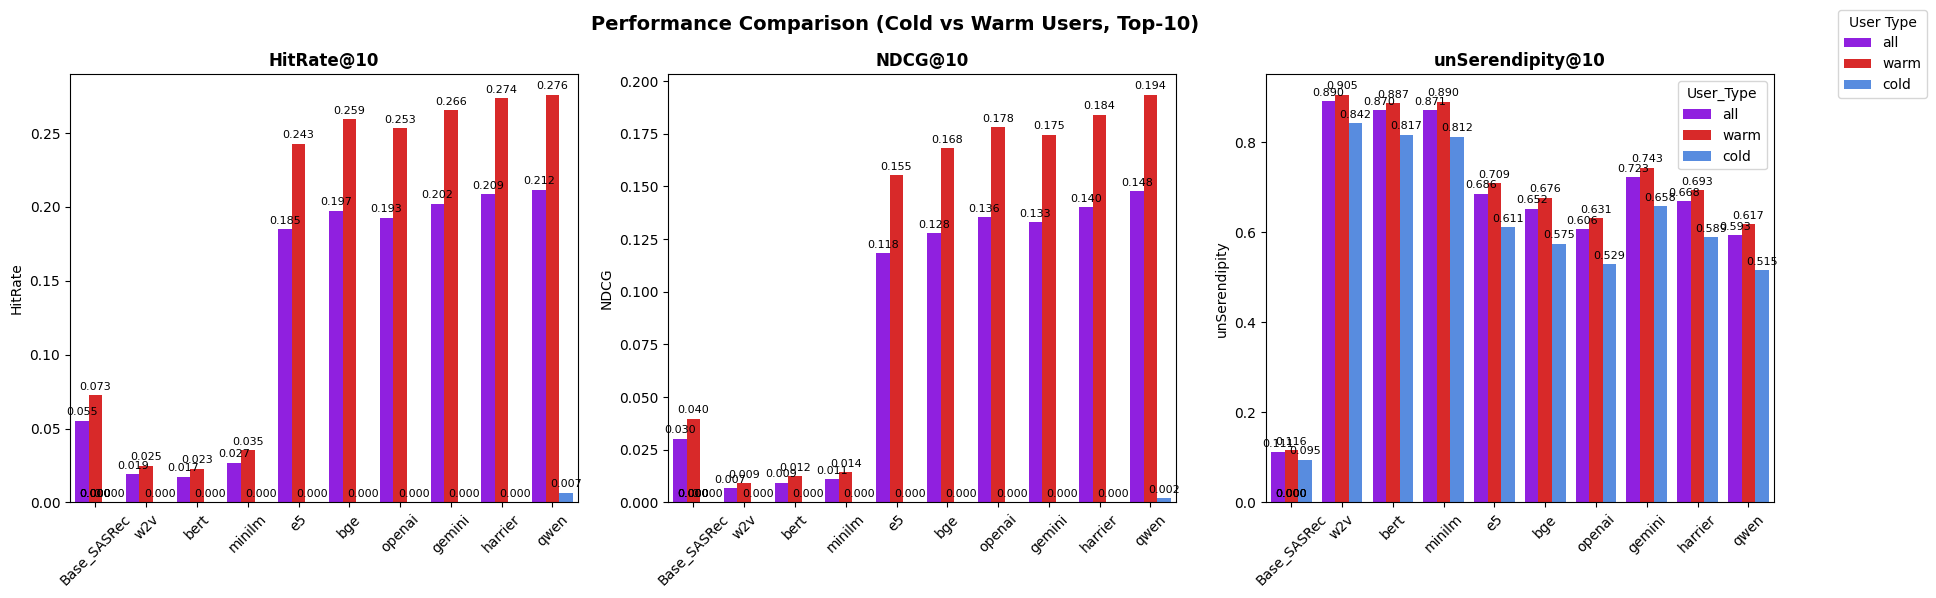

In [61]:
plot_cold_vs_warm_multi(df_master, k_val=10, weight_profile='None')

# delta bar

Grafik ini menghitung: "Dibandingkan model Base (0%), seberapa persen kita mengorbankan HitRate demi menaikkan unSerendipity?"

In [37]:
def plot_delta_percentage(df, k_val=10, user_type='all', weight_profile='None'):
    df_k = df.copy()
    df_k = df_k.fillna('None')
    df_k = df_k[(df_k['k'] == k_val) & (df_k['User_Type'] == user_type)]
    df_wp = df_k[df_k['Weight_Profile'] == weight_profile]
    
    # Ambil nilai baseline (Base_SASRec)
    base_row = df_k[df_k['Model'] == 'Base_SASRec']
    if base_row.empty:
        print("Base model tidak ditemukan untuk perhitungan Delta!")
        return
        
    base_hit = base_row['HitRate'].values[0]
    base_ndcg = base_row['NDCG'].values[0]
    base_ser = base_row['unSerendipity'].values[0]
    
    # Hitung persentase perubahan (Delta)
    df_wp['Delta_HitRate (%)'] = ((df_wp['HitRate'] - base_hit) / base_hit) * 100
    df_wp['Delta_unSerendipity (%)'] = ((df_wp['unSerendipity'] - base_ser) / base_ser) * 100
    df_wp['Delta_NDCG (%)'] = ((df_wp['NDCG'] - base_ndcg) / base_ndcg) * 100

    # Buang Base model dari plot agar grafik fokus pada varian model saja
    df_plot = df_wp[df_wp['Model'] != 'Base_SASRec'].copy()
    
    # Melt untuk plotting
    df_melt = df_plot.melt(
        id_vars=['Model'], 
        value_vars=['Delta_HitRate (%)', 'Delta_NDCG (%)', 'Delta_unSerendipity (%)'],
        var_name='Metrik', value_name='Perubahan (%)'
    )
    
    plt.figure(figsize=(12, 6))
    
    # Bar plot (bisa bernilai negatif/positif)
    barplot = sns.barplot(
        data=df_melt,
        x='Model',
        y='Perubahan (%)',
        hue='Metrik',
        palette=['#d62728', '#2ca02c', '#3c6bfa'],
        errorbar=None
    )
    
    # Garis nol (Baseline)
    plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
    
    weight_label = '' if weight_profile == 'None' else weight_profile
    plt.title(f'Difference in Performance (Top-{k_val}) on {user_type} test set {weight_label}', fontsize=14, fontweight='bold')
    plt.xlabel('Varians', fontsize=12)
    plt.ylabel('Difference (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Label nilai persen
    for p in barplot.patches:
        val = p.get_height()
        if not np.isnan(val):
            # Posisi teks: Jika positif di atas bar, jika negatif di bawah bar
            y_offset = 6 if val > 0 else -8
            barplot.annotate(f'{val:+.1f}%',
                            (p.get_x() + p.get_width() / 2., val), 
                            ha = 'center', va = 'center', 
                            xytext = (0, y_offset),
                            textcoords = 'offset points',
                            fontsize=8, fontweight='bold')

    plt.legend(title='Metrik vs Base')
    plt.tight_layout()
    plt.show()

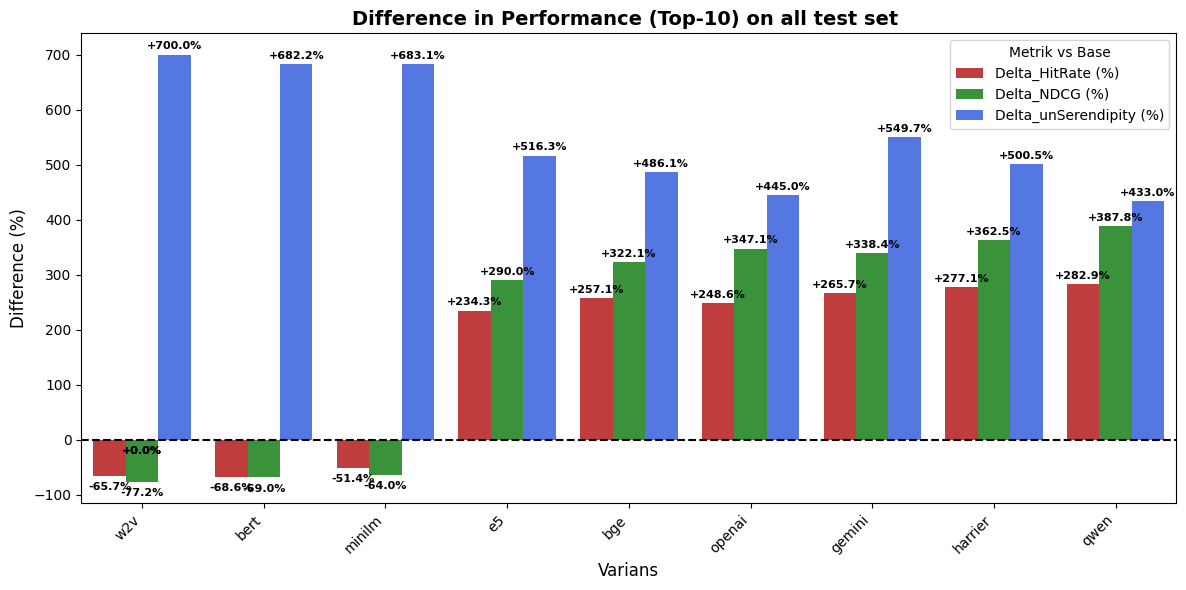

In [38]:
plot_delta_percentage(df_master_all_users, k_val=10)

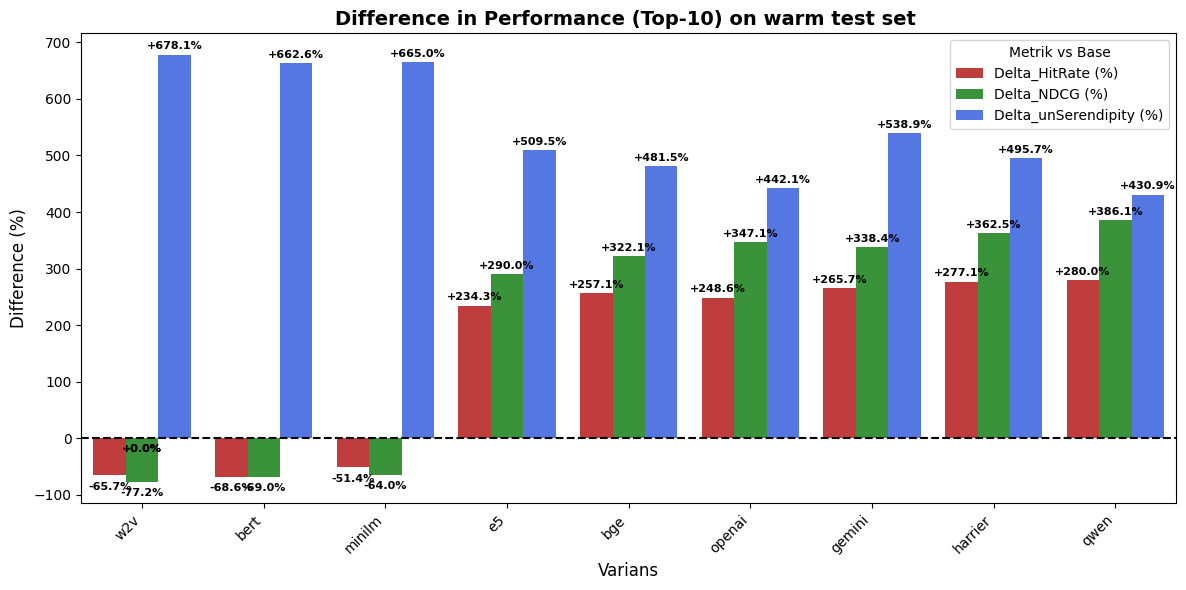

In [39]:
plot_delta_percentage(df_master, k_val=10, user_type='warm')

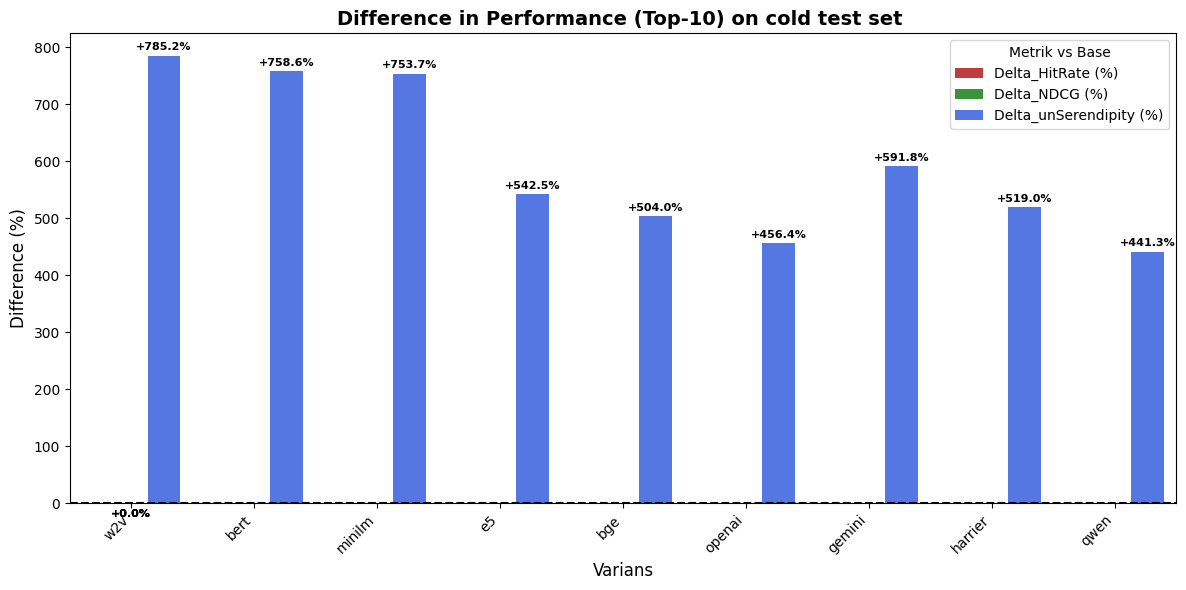

In [40]:
plot_delta_percentage(df_master, k_val=10, user_type='cold')

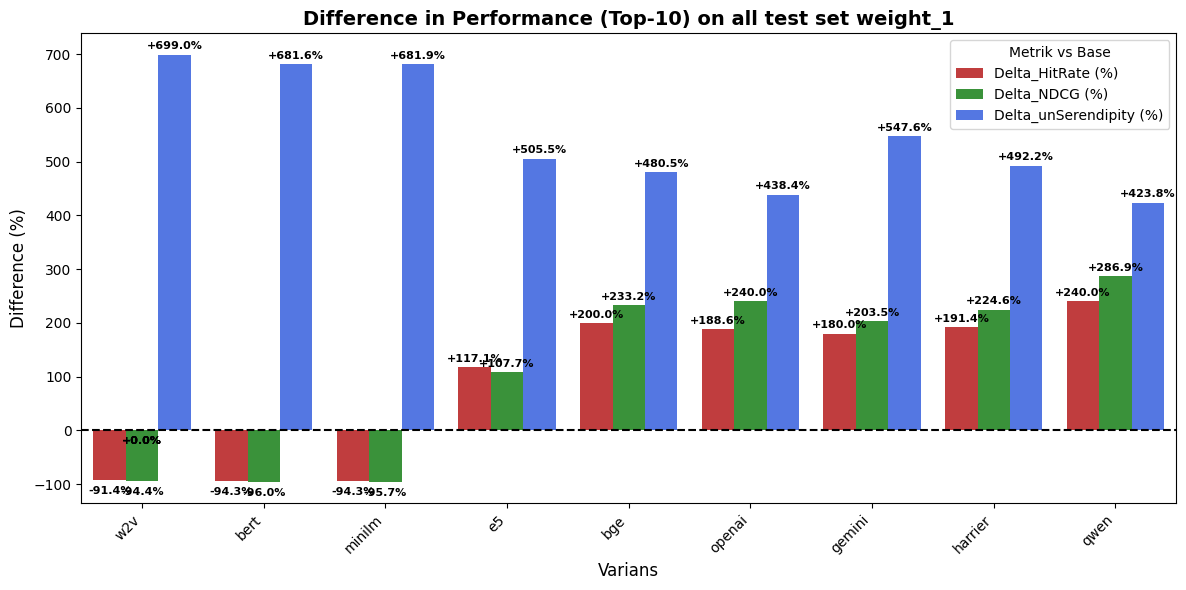

In [41]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_1')

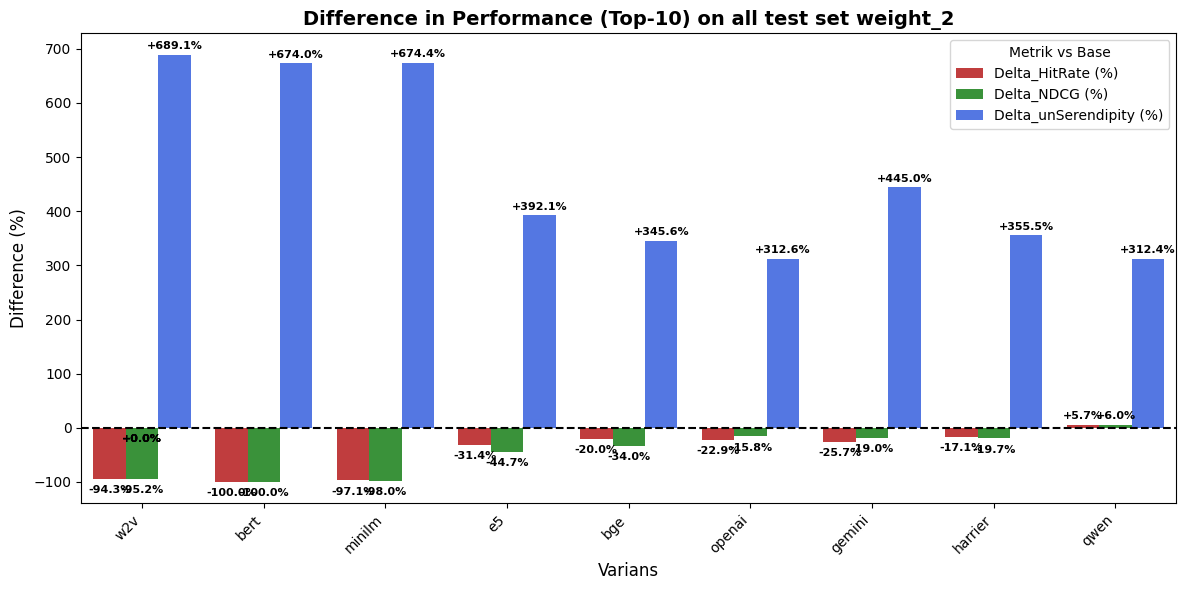

In [42]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_2')

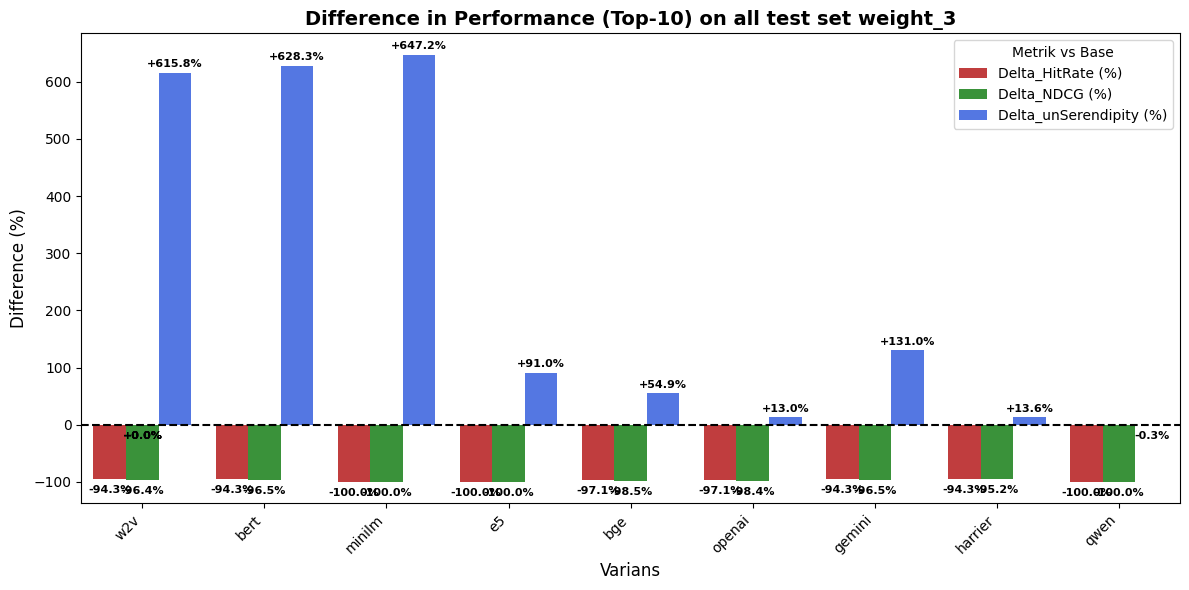

In [43]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_3')

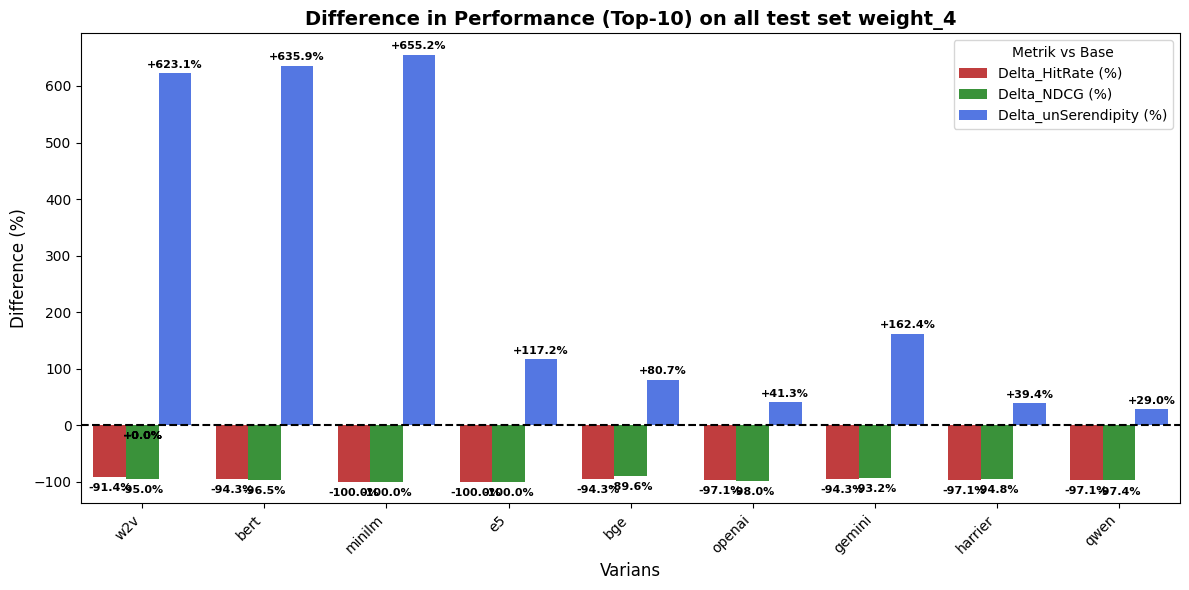

In [44]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_4')

# Table

In [45]:
def summary_table(df, k_val=10, weight_profile='None'):
    df_k = df.copy()
    df_k = df_k.fillna('None')
    df_k = df_k[(df_k['k'] == k_val) & (df_k['Weight_Profile'] == weight_profile)]
    
    df_k = df_k[['Model', 'User_Type', 'HitRate', 'NDCG', 'unSerendipity']]
    
    df_k = df_k.rename(columns={
        'Model': 'Varian Model',
        'User_Type': 'Skenario',
        'HitRate': f'HitRate@{k_val}',
        'NDCG': f'NDCG@{k_val}',
        'unSerendipity': f'unSerendipity@{k_val}'
    })
    
    df_k['Skenario'] = df_k['Skenario'].str.capitalize()
    
    df_k['Skenario'] = pd.Categorical(df_k['Skenario'], categories=['Warm', 'Cold'], ordered=True)
    df_k = df_k.sort_values(by=['Varian Model', 'Skenario']).reset_index(drop=True)
    
    tabel_rapi = df_k.style.format({
        f'HitRate@{k_val}': '{:.3f}',
        f'NDCG@{k_val}': '{:.3f}',
        f'unSerendipity@{k_val}': '{:.3f}'
    }).hide(axis="index")
    display(tabel_rapi)

In [46]:
summary_table(df_master, k_val=10, weight_profile='None')

C:\Users\reera\AppData\Local\Temp\ipykernel_23152\2209812128.py:18: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_k['Skenario'] = pd.Categorical(df_k['Skenario'], categories=['Warm', 'Cold'], ordered=True)


Varian Model,Skenario,HitRate@10,NDCG@10,unSerendipity@10
Base_SASRec,Warm,0.073,0.040,0.116
Base_SASRec,Cold,0.000,0.000,0.095
Base_SASRec,nan,0.055,0.030,0.111
bert,Warm,0.023,0.012,0.887
bert,Cold,0.000,0.000,0.817
bert,nan,0.017,0.009,0.870
bge,Warm,0.259,0.168,0.676
bge,Cold,0.000,0.000,0.575
bge,nan,0.197,0.128,0.652
e5,Warm,0.243,0.155,0.709


# T-paired test

In [47]:
from scipy import stats

def paired_t_test(df, model_baseline, model_eksperimen, metric, user_type='all'):
    """
    Melakukan Paired T-Test antara dua model berdasarkan K yang sama.
    """
    df_base = df[(df['Model'] == model_baseline) & (df['User_Type'] == user_type)].copy()
    df_eksp = df[(df['Model'] == model_eksperimen) & (df['User_Type'] == user_type)].copy()

    df_base = df_base.fillna('None')
    df_eksp = df_eksp.fillna('None')
    
    df_base = df_base[df_base['Weight_Profile'] == 'None']
    df_eksp = df_eksp[df_eksp['Weight_Profile'] == 'None']
    
    # Pastikan data diurutkan berdasarkan 'k' agar pasangannya tepat (K=2 di-pair dgn K=2)
    df_base = df_base.sort_values('k').reset_index(drop=True)
    df_eksp = df_eksp.sort_values('k').reset_index(drop=True)
    
    # Validasi jumlah sampel
    if len(df_base) != len(df_eksp) or len(df_base) == 0:
        print(f"Error: Data tidak seimbang untuk di-pair. {model_baseline} punya {len(df_base)} baris, {model_eksperimen} punya {len(df_eksp)} baris.")
        return
        
    skor_base = df_base[metric].values
    skor_eksp = df_eksp[metric].values
    
    # Uji Statistik (Sekarang sampel N = jumlah variasi K)
    t_stat, p_value = stats.ttest_rel(skor_base, skor_eksp)
    
    alpha = 0.05
    rata_base = skor_base.mean()
    rata_eksp = skor_eksp.mean()
    
    is_significant = p_value < alpha
    
    # Cek apakah eksperimen lebih baik
    if metric == 'unSerendipity':
        # unSerendipity lebih kecil = novelty lebih tinggi / serendipity lebih baik
        lebih_baik = rata_eksp < rata_base # <-- SAYA PERBAIKI LOGIKANYA DI SINI (LEBIH KECIL LEBIH BAIK)
    else:
        # HitRate / NDCG lebih besar = lebih baik
        lebih_baik = rata_eksp > rata_base
    
    print(f"--- UJI PAIRED T-TEST: {model_baseline} vs {model_eksperimen} ---")
    print(f"Metrik      : {metric} (Skenario: {user_type})")
    print(f"Rata-rata   : {model_baseline} = {rata_base:.4f} | {model_eksperimen} = {rata_eksp:.4f}")
    print(f"T-Statistic : {t_stat:.4f}")
    print(f"P-Value     : {p_value:.5f}") # Format 5 desimal agar p-value yg kecil (misal 0.0001) terlihat
    
    if is_significant:
        keterangan = "LEBIH BAIK secara SIGNIFIKAN" if lebih_baik else "MENURUN secara SIGNIFIKAN"
        print(f"Kesimpulan  : Performa {model_eksperimen} {keterangan} dibandingkan {model_baseline} (p < 0.05).")
    else:
        print("Kesimpulan  : Perbedaan performa TIDAK SIGNIFIKAN secara statistik (p >= 0.05).")
    print("-" * 60)


In [48]:
paired_t_test(df_master, model_baseline='Base_SASRec', model_eksperimen='qwen', metric='HitRate', user_type='all')

--- UJI PAIRED T-TEST: Base_SASRec vs qwen ---
Metrik      : HitRate (Skenario: all)
Rata-rata   : Base_SASRec = 0.0662 | qwen = 0.2385
T-Statistic : -17.3883
P-Value     : 0.00000
Kesimpulan  : Performa qwen LEBIH BAIK secara SIGNIFIKAN dibandingkan Base_SASRec (p < 0.05).
------------------------------------------------------------


In [49]:
def significant_test(df, model_baseline='Base_SASRec', metric='HitRate', user_type='all'):
    hasil_uji = []
    
    # Dapatkan semua model eksperimen selain baseline
    model_eksperimen_list = [m for m in df['Model'].unique() if m != model_baseline]
    
    for model_eksp in model_eksperimen_list:
        # Filter & Sort
        df_base = df[(df['Model'] == model_baseline) & (df['User_Type'] == user_type)].copy()
        df_eksp = df[(df['Model'] == model_eksp) & (df['User_Type'] == user_type)].copy()

        df_base = df_base.fillna('None')
        df_eksp = df_eksp.fillna('None')
        
        df_base = df_base[df_base['Weight_Profile'] == 'None']
        df_eksp = df_eksp[df_eksp['Weight_Profile'] == 'None']
        
        if len(df_base) == len(df_eksp) and len(df_base) > 0:
            skor_base = df_base[metric].values
            skor_eksp = df_eksp[metric].values
            
            # Hitung T-Test
            t_stat, p_value = stats.ttest_rel(skor_base, skor_eksp)
            rata_base = skor_base.mean()
            rata_eksp = skor_eksp.mean()
            selisih = rata_eksp - rata_base
            
            hasil_uji.append({
                'Experiment': model_eksp,
                'Average Base': rata_base,
                'Average Eksp': rata_eksp,
                'Difference': selisih,
                'P-Value': p_value,
                'Is Significant (p < 0.05)': "Yes" if p_value < 0.05 else "No"
            })
            
    # Jadikan dataframe agar rapi
    df_hasil = pd.DataFrame(hasil_uji)
    
    # Berikan gaya formatting pada tabel
    tabel_rapi = df_hasil.style.format({
        'Average Base': '{:.4f}',
        'Average Eksp': '{:.4f}',
        'Difference': '{:+.4f}',
        'P-Value': '{:.5f}'
    }).hide(axis="index")
    
    print(f"REKAP UJI SIGNIFIKANSI {metric.upper()} PADA SKENARIO '{user_type.upper()}'")
    print(f"(Baseline: {model_baseline})")
    display(tabel_rapi)

In [50]:
significant_test(df_master, model_baseline='Base_SASRec', metric='HitRate', user_type='cold')

REKAP UJI SIGNIFIKANSI HITRATE PADA SKENARIO 'COLD'
(Baseline: Base_SASRec)


Experiment,Average Base,Average Eksp,Difference,P-Value,Is Significant (p < 0.05)
w2v,0.0000,0.0000,+0.0000,nan,No
bert,0.0000,0.0000,+0.0000,nan,No
minilm,0.0000,0.0033,+0.0033,0.02609,Yes
e5,0.0000,0.0000,+0.0000,nan,No
bge,0.0000,0.0000,+0.0000,nan,No
openai,0.0000,0.0039,+0.0039,0.00238,Yes
gemini,0.0000,0.0000,+0.0000,nan,No
harrier,0.0000,0.0000,+0.0000,nan,No
qwen,0.0000,0.0055,+0.0055,0.00040,Yes


In [51]:
significant_test(df_master, model_baseline='Base_SASRec', metric='HitRate', user_type='warm')

REKAP UJI SIGNIFIKANSI HITRATE PADA SKENARIO 'WARM'
(Baseline: Base_SASRec)


Experiment,Average Base,Average Eksp,Difference,P-Value,Is Significant (p < 0.05)
w2v,0.0870,0.0405,-0.0465,0.00000,Yes
bert,0.0870,0.0463,-0.0406,0.00000,Yes
minilm,0.0870,0.0418,-0.0451,0.00000,Yes
e5,0.0870,0.2640,+0.1770,0.00000,Yes
bge,0.0870,0.2894,+0.2025,0.00000,Yes
openai,0.0870,0.2849,+0.1980,0.00000,Yes
gemini,0.0870,0.2958,+0.2089,0.00000,Yes
harrier,0.0870,0.3034,+0.2165,0.00000,Yes
qwen,0.0870,0.3115,+0.2246,0.00000,Yes


In [52]:
significant_test(df_master, model_baseline='Base_SASRec', metric='HitRate', user_type='all')

REKAP UJI SIGNIFIKANSI HITRATE PADA SKENARIO 'ALL'
(Baseline: Base_SASRec)


Experiment,Average Base,Average Eksp,Difference,P-Value,Is Significant (p < 0.05)
w2v,0.0662,0.0308,-0.0354,0.00000,Yes
bert,0.0662,0.0353,-0.0309,0.00000,Yes
minilm,0.0662,0.0326,-0.0336,0.00000,Yes
e5,0.0662,0.2010,+0.1348,0.00000,Yes
bge,0.0662,0.2204,+0.1542,0.00000,Yes
openai,0.0662,0.2179,+0.1517,0.00000,Yes
gemini,0.0662,0.2253,+0.1590,0.00000,Yes
harrier,0.0662,0.2310,+0.1648,0.00000,Yes
qwen,0.0662,0.2385,+0.1723,0.00000,Yes
